# 🌐 Язык / Language

**RU.** Выберите язык в ячейке ниже: `LANG = "ru"` или `LANG = "en"`, затем запустите
блокнот целиком (Run All). На выбранном языке будет весь текст: пояснения, выводы ячеек,
заголовки, подписи и легенды графиков.

**EN.** Choose the language in the cell below: `LANG = "ru"` or `LANG = "en"`, then run
the whole notebook (Run All). Everything will be in that language: the explanations, the
cell outputs, chart titles, labels and legends.


In [37]:
import sys
import seasonal_toolbox as sx

print(sys.executable)
print("seasonal_toolbox", sx.__version__, "|", sx.__file__)
print("x13as:", sx.X13_BIN or "не задан -- используются встроенные реализации")


/opt/anaconda3/bin/python
seasonal_toolbox 1.1 | /Users/mike/Programming/PYTHON/SEASONAL_ADJUSTMENTS_GIT/seasonal_toolbox.py
x13as: /Users/mike/Programming/PYTHON/SEASONAL_ADJUSTMENTS_GIT/x13as


In [38]:
LANG = "ru"   # "ru" -- русский | "en" -- English

# Autoreload: edits to seasonal_toolbox.py are picked up without restarting the kernel.
# Автоперезагрузка: правки seasonal_toolbox.py подхватываются без перезапуска ядра.
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The whole toolkit lives in seasonal_toolbox.py next to this notebook -- the same module
# as for the full version.
# Весь инструментарий -- в seasonal_toolbox.py рядом с блокнотом; модуль тот же, что и у
# полной версии.
import seasonal_toolbox as sx
sx.set_lang(LANG)
from seasonal_toolbox import *
pal = econ_style("light")

TXT = {
    "lang": {"ru": "Язык блокнота: русский. Модуль seasonal_toolbox, версия {0}.",
             "en": "Notebook language: English. Module seasonal_toolbox, version {0}."},
}
print(tx(TXT["lang"]).format(sx.__version__))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Язык блокнота: русский. Модуль seasonal_toolbox, версия 1.1.


In [39]:
MD = {
"ru": r"""
# Сезонная корректировка: короткая версия

**Зачем это нужно.** Почти любой экономический показатель «дышит» вместе с календарём: розница
растёт в декабре, стройка замирает зимой, в январе всё проседает из-за праздников. Если сравнивать
соседние месяцы «как есть», мы будем видеть календарь, а не экономику. Сезонная корректировка
убирает календарную волну, чтобы стало видно, что происходит на самом деле.

**Как устроен этот блокнот.** История методов сезонной корректировки -- это цепочка: каждый новый
метод появился, потому что у предыдущего нашлась конкретная проблема. Мы пройдём эту цепочку и
для каждого шага ответим на два вопроса: *какую проблему он решил* и *что осталось нерешённым*.

**План**

1. Что такое сезонность
2. Как проверить, что сезонность ушла
3. Данные до корректировки: уровни или темпы, логарифм, календарь, выбросы
4. Эволюция методов: от Census Method I до X-13ARIMA-SEATS
5. Методы вне этой линии: STL, MSTL, TBATS, Prophet, UCM, вейвлеты
6. Что аналитик видит на выходе: 3MMA SAAR и прогноз
7. Одна функция для реальных данных: `analyze_series()`
8. Открытые вопросы
9. Итоговая таблица

Все данные в примерах синтетические: мы сами знаем «истинную» сезонность и можем честно
измерить, насколько точно её восстанавливает каждый метод. Подробности, доказательства и работа
с настоящим бинарником X-13 -- в полной версии блокнота.
""",
"en": r"""
# Seasonal adjustment: the short version

**Why it is needed.** Almost every economic indicator "breathes" with the calendar: retail rises in
December, construction freezes in winter, everything dips in January because of the holidays. If we
compare neighbouring months "as is", we see the calendar rather than the economy. Seasonal adjustment
removes the calendar wave so that what is really happening becomes visible.

**How this notebook is organised.** The history of seasonal adjustment methods is a chain: each new
method appeared because a specific problem was found in the previous one. We will walk along this
chain and for each step answer two questions: *which problem it solved* and *what remained unsolved*.

**Plan**

1. What seasonality is
2. How to check that the seasonality is gone
3. Data before adjustment: levels or rates, logarithm, calendar, outliers
4. Evolution of methods: from Census Method I to X-13ARIMA-SEATS
5. Methods outside this line: STL, MSTL, TBATS, Prophet, UCM, wavelets
6. What the analyst sees at the output: 3MMA SAAR and the forecast
7. One function for real data: `analyze_series()`
8. Open questions
9. Summary table

All the data in the examples are synthetic: we know the "true" seasonality ourselves and can measure
honestly how accurately each method recovers it. Details, proofs and work with the real X-13 binary
are in the full version of the notebook.
""",
}
show_md(MD)



# Сезонная корректировка: короткая версия

**Зачем это нужно.** Почти любой экономический показатель «дышит» вместе с календарём: розница
растёт в декабре, стройка замирает зимой, в январе всё проседает из-за праздников. Если сравнивать
соседние месяцы «как есть», мы будем видеть календарь, а не экономику. Сезонная корректировка
убирает календарную волну, чтобы стало видно, что происходит на самом деле.

**Как устроен этот блокнот.** История методов сезонной корректировки -- это цепочка: каждый новый
метод появился, потому что у предыдущего нашлась конкретная проблема. Мы пройдём эту цепочку и
для каждого шага ответим на два вопроса: *какую проблему он решил* и *что осталось нерешённым*.

**План**

1. Что такое сезонность
2. Как проверить, что сезонность ушла
3. Данные до корректировки: уровни или темпы, логарифм, календарь, выбросы
4. Эволюция методов: от Census Method I до X-13ARIMA-SEATS
5. Методы вне этой линии: STL, MSTL, TBATS, Prophet, UCM, вейвлеты
6. Что аналитик видит на выходе: 3MMA SAAR и прогноз
7. Одна функция для реальных данных: `analyze_series()`
8. Открытые вопросы
9. Итоговая таблица

Все данные в примерах синтетические: мы сами знаем «истинную» сезонность и можем честно
измерить, насколько точно её восстанавливает каждый метод. Подробности, доказательства и работа
с настоящим бинарником X-13 -- в полной версии блокнота.


In [40]:
MD = {
"ru": r"""
## 1. Что такое сезонность

Ряд удобно представить как сумму трёх частей:

$$Y_t = T_t + S_t + I_t$$

- **тренд** `T` -- медленное движение (рост экономики, инфляция);
- **сезонность** `S` -- волна, которая повторяется каждый год;
- **шум** `I` -- всё случайное и разовое.

Сезонная корректировка -- это оценка `S` и её вычитание: `SA = Y − S`.

**Важная развилка -- аддитивная или мультипликативная сезонность.** В аддитивной модели сезонный
размах постоянен в единицах ряда («декабрь всегда +80 млрд руб.»). В мультипликативной он постоянен
в процентах («декабрь всегда +18%») и поэтому в рублях растёт вместе с уровнем. Все показатели в
текущих ценах -- выручка, зарплаты, экспорт -- обычно мультипликативные. Такую модель сводят к
аддитивной логарифмом: `log Y = log T + log S + log I`.

**Календарные эффекты** -- отдельная история: число рабочих дней в месяце и дата Пасхи меняются
год от года, поэтому их не «усредняют», а учитывают явно (раздел 3).
""",
"en": r"""
## 1. What seasonality is

It is convenient to think of a series as the sum of three parts:

$$Y_t = T_t + S_t + I_t$$

- the **trend** `T` -- slow movement (economic growth, inflation);
- the **seasonality** `S` -- a wave that repeats every year;
- the **noise** `I` -- everything random and one-off.

Seasonal adjustment means estimating `S` and subtracting it: `SA = Y − S`.

**An important fork -- additive or multiplicative seasonality.** In the additive model the seasonal
swing is constant in the units of the series ("December is always +80 bn roubles"). In the
multiplicative model it is constant in percent ("December is always +18%"), so in roubles it grows
together with the level. All indicators in current prices -- revenue, wages, exports -- are usually
multiplicative. Such a model is reduced to an additive one with a logarithm:
`log Y = log T + log S + log I`.

**Calendar effects** are a separate story: the number of working days in a month and the date of
Easter change from year to year, so they are not "averaged out" but accounted for explicitly
(section 3).
""",
}
show_md(MD)



## 1. Что такое сезонность

Ряд удобно представить как сумму трёх частей:

$$Y_t = T_t + S_t + I_t$$

- **тренд** `T` -- медленное движение (рост экономики, инфляция);
- **сезонность** `S` -- волна, которая повторяется каждый год;
- **шум** `I` -- всё случайное и разовое.

Сезонная корректировка -- это оценка `S` и её вычитание: `SA = Y − S`.

**Важная развилка -- аддитивная или мультипликативная сезонность.** В аддитивной модели сезонный
размах постоянен в единицах ряда («декабрь всегда +80 млрд руб.»). В мультипликативной он постоянен
в процентах («декабрь всегда +18%») и поэтому в рублях растёт вместе с уровнем. Все показатели в
текущих ценах -- выручка, зарплаты, экспорт -- обычно мультипликативные. Такую модель сводят к
аддитивной логарифмом: `log Y = log T + log S + log I`.

**Календарные эффекты** -- отдельная история: число рабочих дней в месяце и дата Пасхи меняются
год от года, поэтому их не «усредняют», а учитывают явно (раздел 3).


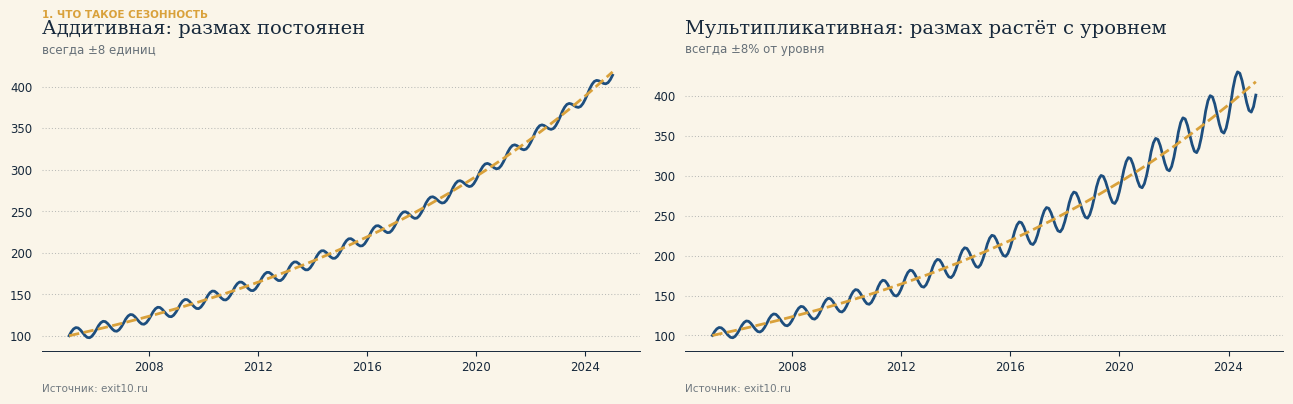

Размах сезонной волны в первый и последний год: аддитивная 16.0 -> 16.0, мультипликативная 16.6 -> 64.9.


In [41]:
TXT = {
    "sec":   {"ru": "Что такое сезонность", "en": "What seasonality is"},
    "t_add": {"ru": "Аддитивная: размах постоянен", "en": "Additive: the swing is constant"},
    "s_add": {"ru": "всегда ±8 единиц", "en": "always ±8 units"},
    "t_mul": {"ru": "Мультипликативная: размах растёт с уровнем", "en": "Multiplicative: the swing grows with the level"},
    "s_mul": {"ru": "всегда ±8% от уровня", "en": "always ±8% of the level"},
    "obs":   {"ru": "Размах сезонной волны в первый и последний год: аддитивная {0:.1f} -> {1:.1f}, мультипликативная {2:.1f} -> {3:.1f}.",
              "en": "Seasonal swing in the first and the last year: additive {0:.1f} -> {1:.1f}, multiplicative {2:.1f} -> {3:.1f}."},
}
set_section("1", TXT["sec"])

t = np.arange(240)
dates = pd.date_range("2005-01-31", periods=240, freq="ME")
trend = 100 * 1.006**t
y_add = trend + 8 * np.sin(2*np.pi*t/12)
y_mul = trend * (1 + 0.08*np.sin(2*np.pi*t/12))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(dates, y_add, color=pal["lazur"]); axes[0].plot(dates, trend, "--", color=pal["zoloto"])
chart_frame(axes[0], tx(TXT["t_add"]), tx(TXT["s_add"]), pal=pal)
axes[1].plot(dates, y_mul, color=pal["lazur"]); axes[1].plot(dates, trend, "--", color=pal["zoloto"])
chart_frame(axes[1], tx(TXT["t_mul"]), tx(TXT["s_mul"]), pal=pal)
plt.tight_layout(); plt.show()

swing = lambda s, a, b: np.ptp(s[a:b])
print(tx(TXT["obs"]).format(swing(y_add - trend, 0, 12), swing(y_add - trend, -12, None),
                            swing(y_mul - trend, 0, 12), swing(y_mul - trend, -12, None)))


In [42]:
MD = {
"ru": r"""
## 2. Как проверить, что сезонность ушла

Посмотреть на график и сказать «стало глаже» -- мало. Нужны числа. Мы используем три проверки, и
все три отвечают на один и тот же вопрос с разных сторон.

1. **Автокорреляция на лаге 12.** Похож ли январь на прошлогодний январь? Если после корректировки
   ответ всё ещё «да», сезонность осталась. При этом высокая автокорреляция на **лаге 1** -- это
   нормально: экономика инерционна, и сезонная корректировка не должна это «лечить».
2. **Периодограмма.** Раскладывает колебания ряда по частотам. У сезонного ряда -- острые пики на
   1, 2, … 6 циклах в год. После корректировки пики должны исчезнуть.
3. **Доля сезонной мощности.** Одно число: какая часть всей изменчивости ряда приходится на
   сезонные частоты. До корректировки она заметная, после -- близка к нулю.

Все три считает одна функция `evaluate_seasonality()`, и она одинаково работает для любого метода.
""",
"en": r"""
## 2. How to check that the seasonality is gone

Looking at a chart and saying "it got smoother" is not enough. We need numbers. We use three checks,
and all three answer the same question from different sides.

1. **Autocorrelation at lag 12.** Does January look like last year's January? If after adjustment the
   answer is still "yes", the seasonality has remained. At the same time a high autocorrelation at
   **lag 1** is normal: the economy has inertia, and seasonal adjustment should not "cure" it.
2. **The periodogram.** It splits the fluctuations of a series by frequency. A seasonal series has sharp
   peaks at 1, 2, … 6 cycles a year. After adjustment the peaks should disappear.
3. **The share of seasonal power.** One number: what part of all the variability of the series falls on
   the seasonal frequencies. Before adjustment it is noticeable, after -- close to zero.

All three are computed by one function, `evaluate_seasonality()`, and it works the same way for any
method.
""",
}
show_md(MD)



## 2. Как проверить, что сезонность ушла

Посмотреть на график и сказать «стало глаже» -- мало. Нужны числа. Мы используем три проверки, и
все три отвечают на один и тот же вопрос с разных сторон.

1. **Автокорреляция на лаге 12.** Похож ли январь на прошлогодний январь? Если после корректировки
   ответ всё ещё «да», сезонность осталась. При этом высокая автокорреляция на **лаге 1** -- это
   нормально: экономика инерционна, и сезонная корректировка не должна это «лечить».
2. **Периодограмма.** Раскладывает колебания ряда по частотам. У сезонного ряда -- острые пики на
   1, 2, … 6 циклах в год. После корректировки пики должны исчезнуть.
3. **Доля сезонной мощности.** Одно число: какая часть всей изменчивости ряда приходится на
   сезонные частоты. До корректировки она заметная, после -- близка к нулю.

Все три считает одна функция `evaluate_seasonality()`, и она одинаково работает для любого метода.


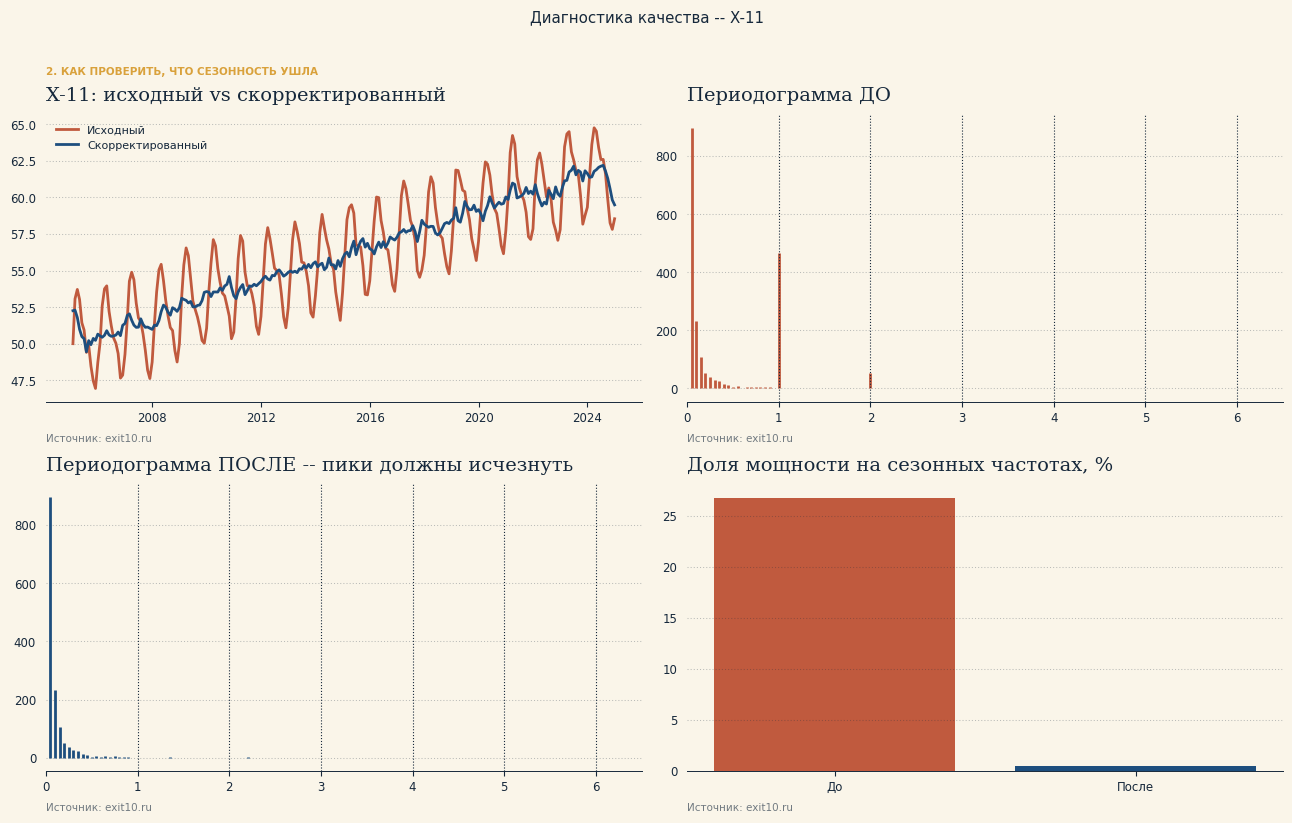

Автокорреляция: лаг 1 до 0.81 / после 0.65 (инерция, это нормально);  лаг 12 до 0.90 / после -0.23 (сезонность)
Доля сезонной мощности: до 26.8%, после 0.43%.


In [43]:
TXT = {
    "sec": {"ru": "Как проверить, что сезонность ушла", "en": "How to check that the seasonality is gone"},
    "acf": {"ru": "Автокорреляция: лаг 1 до {0:.2f} / после {1:.2f} (инерция, это нормально);  лаг 12 до {2:.2f} / после {3:.2f} (сезонность)",
            "en": "Autocorrelation: lag 1 before {0:.2f} / after {1:.2f} (inertia, this is normal);  lag 12 before {2:.2f} / after {3:.2f} (seasonality)"},
    "shr": {"ru": "Доля сезонной мощности: до {0:.1%}, после {1:.2%}.",
            "en": "Share of seasonal power: before {0:.1%}, after {1:.2%}."},
    "verdict": {"ru": "Вывод функции:", "en": "The function's verdict:"},
}
set_section("2", TXT["sec"])

np.random.seed(1)
t = np.arange(240)
dates = pd.date_range("2005-01-31", periods=240, freq="ME")
noise = np.zeros(240)
for k in range(1, 240):
    noise[k] = 0.6*noise[k-1] + np.random.normal(0, 0.4)      # economic inertia | инерция экономики
y = 50 + 0.05*t + 3*np.sin(2*np.pi*t/12) + np.sin(4*np.pi*t/12) + noise

sa = x11_lite(y)["sa"]                                          # seasonal adjustment | сезонная корректировка
m = evaluate_seasonality(y, sa, dates, show_chart=True, method_name="X-11")

a0, a1 = acf(y - np.polyval(np.polyfit(t, y, 1), t), 12), acf(sa - np.polyval(np.polyfit(t, sa, 1), t), 12)
print(tx(TXT["acf"]).format(a0[1], a1[1], a0[12], a1[12]))
print(tx(TXT["shr"]).format(m["seasonal_power_share_before"], m["seasonal_power_share_after"]))


In [44]:
MD = {
"ru": r"""
## 3. Данные до корректировки: четыре решения

До того как запускать любой метод, нужно принять четыре решения. Ошибка в любом из них испортит
результат сильнее, чем выбор между методами.

**3.1. Уровни, а не темпы.** Росстат часто публикует темпы «месяц к месяцу». Корректировать надо
**уровень**, восстановленный из темпов. Причина в выбросах: постоянный сдвиг уровня (например,
повышение тарифов) в ряде темпов выглядит как разовый всплеск, и алгоритм примет его за временный.
Правильный порядок: темп → уровень → корректировка → обратно в темпы.

**3.2. Логарифмировать или нет.** Если сезонный размах растёт вместе с уровнем, нужен логарифм. Если
забыть -- остаточная сезонность будет **нарастать к концу ряда**, то есть ровно там, где аналитик
смотрит на свежие данные. Ряды с нулями и отрицательными значениями (сальдо, чистый приток)
логарифмировать нельзя. Функция `choose_transform()` решает это автоматически: режет ряд на годы и
проверяет, растёт ли размах вместе с уровнем.
""",
"en": r"""
## 3. Data before adjustment: four decisions

Before running any method, four decisions have to be made. A mistake in any of them spoils the result
more than the choice between methods does.

**3.1. Levels, not rates.** Rosstat often publishes month-on-month rates. What must be adjusted is the
**level** recovered from the rates. The reason is outliers: a permanent shift in the level (say, a tariff
increase) looks like a one-off spike in a series of rates, and the algorithm will take it for a
temporary one. The correct order: rate → level → adjustment → back to rates.

**3.2. To take logarithms or not.** If the seasonal swing grows with the level, a logarithm is needed.
If you forget, residual seasonality will **grow towards the end of the series** -- exactly where the
analyst looks at fresh data. Series with zeros and negative values (balances, net flows) cannot be
logged. The function `choose_transform()` decides this automatically: it cuts the series into years and
checks whether the swing grows with the level.
""",
}
show_md(MD)



## 3. Данные до корректировки: четыре решения

До того как запускать любой метод, нужно принять четыре решения. Ошибка в любом из них испортит
результат сильнее, чем выбор между методами.

**3.1. Уровни, а не темпы.** Росстат часто публикует темпы «месяц к месяцу». Корректировать надо
**уровень**, восстановленный из темпов. Причина в выбросах: постоянный сдвиг уровня (например,
повышение тарифов) в ряде темпов выглядит как разовый всплеск, и алгоритм примет его за временный.
Правильный порядок: темп → уровень → корректировка → обратно в темпы.

**3.2. Логарифмировать или нет.** Если сезонный размах растёт вместе с уровнем, нужен логарифм. Если
забыть -- остаточная сезонность будет **нарастать к концу ряда**, то есть ровно там, где аналитик
смотрит на свежие данные. Ряды с нулями и отрицательными значениями (сальдо, чистый приток)
логарифмировать нельзя. Функция `choose_transform()` решает это автоматически: режет ряд на годы и
проверяет, растёт ли размах вместе с уровнем.


In [45]:
TXT = {
    "sec":  {"ru": "Логарифмировать или нет", "en": "To take logarithms or not"},
    "hdr":  {"ru": "Что выбирает choose_transform():", "en": "What choose_transform() picks:"},
    "row":  {"ru": "  {0:34s} -> {1}", "en": "  {0:34s} -> {1}"},
    "mul":  {"ru": "выручка в рублях (мультипликативный)", "en": "revenue in roubles (multiplicative)"},
    "add":  {"ru": "индекс с постоянным размахом", "en": "an index with a constant swing"},
    "bal":  {"ru": "сальдо (есть отрицательные)", "en": "a balance (has negative values)"},
    "log":  {"ru": "логарифм", "en": "logarithm"},
    "none": {"ru": "без логарифма", "en": "no logarithm"},
}
set_section("3.2", TXT["sec"])

np.random.seed(2)
t = np.arange(240)
series = {
    "mul": 100*1.008**t*(1 + 0.15*np.sin(2*np.pi*t/12))*np.exp(np.random.normal(0, 0.01, 240)),
    "add": 100 + 0.3*t + 8*np.sin(2*np.pi*t/12) + np.random.normal(0, 1, 240),
    "bal": np.random.normal(0, 5, 240) + 3*np.sin(2*np.pi*t/12),
}
print(tx(TXT["hdr"]))
for key, s in series.items():
    print(tx(TXT["row"]).format(tx(TXT[key]), tx(TXT[choose_transform(s)])))


Что выбирает choose_transform():
  выручка в рублях (мультипликативный) -> логарифм
  индекс с постоянным размахом       -> без логарифма
  сальдо (есть отрицательные)        -> без логарифма


In [46]:
MD = {
"ru": r"""
**3.3. Календарь: какая Пасха.** Плавающие праздники сдвигают спрос между месяцами. Стандартные
программы (X-13, TRAMO) используют **западную** Пасху. Для российских рядов нужна **православная**:
даты расходятся в большинстве лет, иногда на пять недель, и православная Пасха часто приходится на
май. Регрессор с неправильной датой почти не коррелирует с настоящим эффектом -- календарная
корректировка просто не сработает. В модуле традиция задаётся аргументом
`easter_tradition="orthodox"` (это значение по умолчанию).

**3.4. Выбросы.** Бывают трёх типов: **AO** -- разовый всплеск, **LS** -- сдвиг уровня навсегда,
**TC** -- всплеск, который постепенно затухает. Если их не убрать, они «протекают» в сезонность и
тренд. Алгоритм ищет их перебором: для каждой даты и каждого типа проверяет, значим ли такой выброс, и
добавляет самый значимый. Есть тонкость: у экономических рядов соседние месяцы похожи друг на друга,
и наивный расчёт переоценивает значимость -- находит «выбросы» там, где их нет. Поэтому модуль
сначала **отбеливает** ряд (метод GLS), и только потом ищет.
""",
"en": r"""
**3.3. The calendar: which Easter.** Moving holidays shift demand between months. The standard programs
(X-13, TRAMO) use **Western** Easter. Russian series need **Orthodox** Easter: the dates differ in most
years, sometimes by five weeks, and Orthodox Easter often falls in May. A regressor with the wrong date is
almost uncorrelated with the real effect -- the calendar adjustment simply will not work. In the module
the tradition is set by the argument `easter_tradition="orthodox"` (the default).

**3.4. Outliers.** They come in three types: **AO** -- a one-off spike, **LS** -- a permanent shift in
level, **TC** -- a spike that gradually fades. If they are not removed, they "leak" into the seasonality
and the trend. The algorithm finds them by a sweep: for every date and every type it checks whether such an
outlier is significant, and adds the most significant one. There is a subtlety: in economic series
neighbouring months resemble each other, and a naive calculation overestimates significance -- it finds
"outliers" where there are none. So the module first **whitens** the series (the GLS method), and only then
searches.
""",
}
show_md(MD)



**3.3. Календарь: какая Пасха.** Плавающие праздники сдвигают спрос между месяцами. Стандартные
программы (X-13, TRAMO) используют **западную** Пасху. Для российских рядов нужна **православная**:
даты расходятся в большинстве лет, иногда на пять недель, и православная Пасха часто приходится на
май. Регрессор с неправильной датой почти не коррелирует с настоящим эффектом -- календарная
корректировка просто не сработает. В модуле традиция задаётся аргументом
`easter_tradition="orthodox"` (это значение по умолчанию).

**3.4. Выбросы.** Бывают трёх типов: **AO** -- разовый всплеск, **LS** -- сдвиг уровня навсегда,
**TC** -- всплеск, который постепенно затухает. Если их не убрать, они «протекают» в сезонность и
тренд. Алгоритм ищет их перебором: для каждой даты и каждого типа проверяет, значим ли такой выброс, и
добавляет самый значимый. Есть тонкость: у экономических рядов соседние месяцы похожи друг на друга,
и наивный расчёт переоценивает значимость -- находит «выбросы» там, где их нет. Поэтому модуль
сначала **отбеливает** ряд (метод GLS), и только потом ищет.


In [47]:
TXT = {
    "sec":  {"ru": "Православная и западная Пасха", "en": "Orthodox and Western Easter"},
    "hdr":  {"ru": "{0:>5}  {1:>9}  {2:>12}  {3:>10}", "en": "{0:>5}  {1:>9}  {2:>12}  {3:>10}"},
    "year": {"ru": "год", "en": "year"},
    "west": {"ru": "западная", "en": "Western"},
    "orth": {"ru": "православная", "en": "Orthodox"},
    "gap":  {"ru": "разрыв", "en": "gap"},
    "days": {"ru": "{0} дн.", "en": "{0} days"},
    "corr": {"ru": "Корреляция двух пасхальных регрессоров за 2005-2024: {0:.2f} -- западный почти ничего не говорит о православном.",
             "en": "Correlation of the two Easter regressors over 2005-2024: {0:.2f} -- the Western one says almost nothing about the Orthodox one."},
}
set_section("3.3", TXT["sec"])

print(tx(TXT["hdr"]).format(tx(TXT["year"]), tx(TXT["west"]), tx(TXT["orth"]), tx(TXT["gap"])))
for yr in range(2023, 2028):
    w, o = easter_date(yr, "catholic"), easter_date(yr, "orthodox")
    print(tx(TXT["hdr"]).format(yr, w.strftime("%d.%m"), o.strftime("%d.%m"), tx(TXT["days"]).format((o - w).days)))

d = pd.date_range("2005-01-31", periods=240, freq="ME")
r = np.corrcoef(easter_regressor(d, 8, "catholic", center=True), easter_regressor(d, 8, "orthodox", center=True))[0, 1]
print()
print(tx(TXT["corr"]).format(r))


  год   западная  православная      разрыв
 2023      09.04         16.04       7 дн.
 2024      31.03         05.05      35 дн.
 2025      20.04         20.04       0 дн.
 2026      05.04         12.04       7 дн.
 2027      28.03         02.05      35 дн.

Корреляция двух пасхальных регрессоров за 2005-2024: 0.28 -- западный почти ничего не говорит о православном.


Истина: AO 2010-01, LS 2015-01, TC 2019-03.
без отбеливания:   найдено 7: 2007-05 TC, 2010-01 AO, 2015-01 LS, 2016-02 TC, 2018-06 TC, 2019-03 TC, 2022-05 LS
с отбеливанием:    найдено 5: 2010-01 AO, 2015-01 LS, 2018-12 AO, 2019-03 TC, 2022-05 LS
Ложных находок: без отбеливания 4, с отбеливанием 2. Отбеливание не делает поиск идеальным, но заметно снижает число ложных тревог.


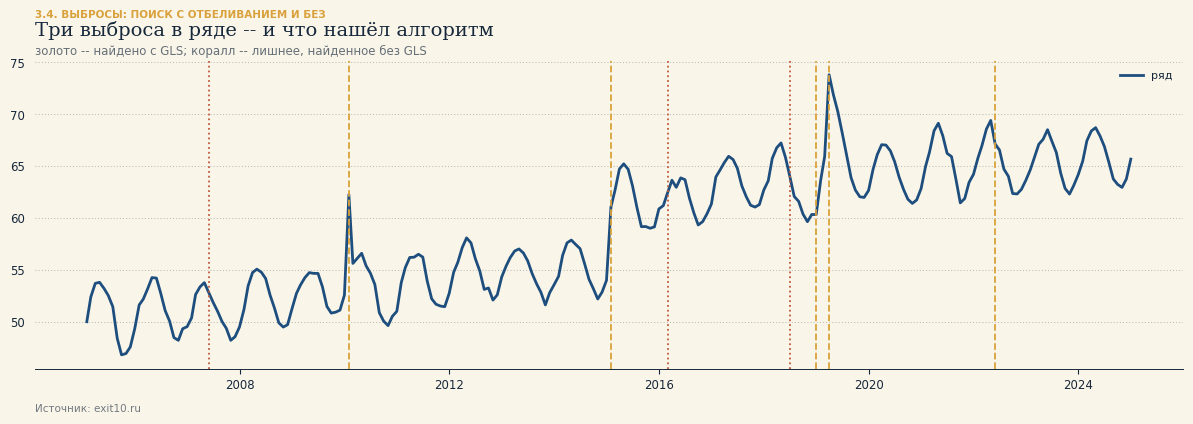

In [48]:
TXT = {
    "sec":   {"ru": "Выбросы: поиск с отбеливанием и без", "en": "Outliers: search with and without whitening"},
    "title": {"ru": "Три выброса в ряде -- и что нашёл алгоритм", "en": "Three outliers in the series -- and what the algorithm found"},
    "sub":   {"ru": "золото -- найдено с GLS; коралл -- лишнее, найденное без GLS", "en": "gold -- found with GLS; coral -- extra, found without GLS"},
    "row":   {"ru": "{0:18s} найдено {1}: {2}", "en": "{0:18s} found {1}: {2}"},
    "ols":   {"ru": "без отбеливания:", "en": "without whitening:"},
    "gls":   {"ru": "с отбеливанием:", "en": "with whitening:"},
    "truth": {"ru": "Истина: AO 2010-01, LS 2015-01, TC 2019-03.", "en": "Truth: AO 2010-01, LS 2015-01, TC 2019-03."},
    "series":{"ru": "ряд", "en": "series"},
    "false": {"ru": "Ложных находок: без отбеливания {0}, с отбеливанием {1}. Отбеливание не делает поиск идеальным, но заметно снижает число ложных тревог.",
              "en": "False findings: without whitening {0}, with whitening {1}. Whitening does not make the search perfect, but it noticeably reduces false alarms."},
}
set_section("3.4", TXT["sec"])

np.random.seed(2024)
n = 240; t = np.arange(n)
dates = pd.date_range("2005-01-31", periods=n, freq="ME")
u = np.zeros(n)
for k in range(1, n):
    u[k] = 0.75*u[k-1] + np.random.normal(0, 0.5)             # autocorrelated noise | автокоррелированный шум
y = 50 + 0.05*t + 3*np.sin(2*np.pi*t/12) + u
y[60] += 9                                                     # AO
y[120:] += 5                                                   # LS
y[170:] += 7*0.7**np.arange(n-170)                             # TC

base, _ = _harmonic_trend_cols(n, 12, 2)
res_ols = auto_outlier_search(y, base, gls=False)
res_gls = auto_outlier_search(y, base, gls=True)
fmt = lambda r: ", ".join(f"{dates[i].strftime('%Y-%m')} {k}" for i, k, _ in sorted(r["outliers"]))

print(tx(TXT["truth"]))
print(tx(TXT["row"]).format(tx(TXT["ols"]), len(res_ols["outliers"]), fmt(res_ols)))
print(tx(TXT["row"]).format(tx(TXT["gls"]), len(res_gls["outliers"]), fmt(res_gls)))
truth = {60: "AO", 120: "LS", 170: "TC"}
n_false = lambda r: sum(1 for i, k, _ in r["outliers"] if truth.get(i) != k)
print(tx(TXT["false"]).format(n_false(res_ols), n_false(res_gls)))

fig, ax = plt.subplots(figsize=(12, 4.4))
ax.plot(dates, y, color=pal["lazur"], label=tx(TXT["series"]))
found_gls = {i for i, _, _ in res_gls["outliers"]}
for i in sorted(found_gls | {i for i, _, _ in res_ols["outliers"]}):
    ax.axvline(dates[i], color=pal["zoloto"] if i in found_gls else pal["korall"],
               linestyle="--" if i in found_gls else ":", linewidth=1.3)
chart_frame(ax, tx(TXT["title"]), tx(TXT["sub"]), pal=pal)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


In [49]:
MD = {
"ru": r"""
## 4. Эволюция методов: каждый решает проблему предыдущего

Дальше -- главная линия, по которой сезонная корректировка развивалась 70 лет, от первых
алгоритмов Бюро переписи США до X-13ARIMA-SEATS, которым сегодня пользуются статслужбы и
центробанки. Возьмём ряд, где мы знаем правду:

- тренд растёт;
- сезонная волна **постепенно усиливается** -- так обычно и бывает в реальных данных;
- есть немного шума и три выброса (AO, LS, TC).

На каждом шаге мерим одно и то же: насколько оценённая сезонность отличается от истинной (RMSE --
средняя ошибка; чем меньше, тем лучше).
""",
"en": r"""
## 4. Evolution of methods: each one solves a problem of the previous one

Next comes the main line along which seasonal adjustment developed over 70 years, from the first
algorithms of the US Census Bureau to X-13ARIMA-SEATS, which statistical offices and central banks use
today. Let us take a series where we know the truth:

- the trend rises;
- the seasonal wave **gradually strengthens** -- as usually happens in real data;
- there is a little noise and three outliers (AO, LS, TC).

At every step we measure the same thing: how far the estimated seasonality is from the true one (RMSE --
the average error; the smaller, the better).
""",
}
show_md(MD)



## 4. Эволюция методов: каждый решает проблему предыдущего

Дальше -- главная линия, по которой сезонная корректировка развивалась 70 лет, от первых
алгоритмов Бюро переписи США до X-13ARIMA-SEATS, которым сегодня пользуются статслужбы и
центробанки. Возьмём ряд, где мы знаем правду:

- тренд растёт;
- сезонная волна **постепенно усиливается** -- так обычно и бывает в реальных данных;
- есть немного шума и три выброса (AO, LS, TC).

На каждом шаге мерим одно и то же: насколько оценённая сезонность отличается от истинной (RMSE --
средняя ошибка; чем меньше, тем лучше).


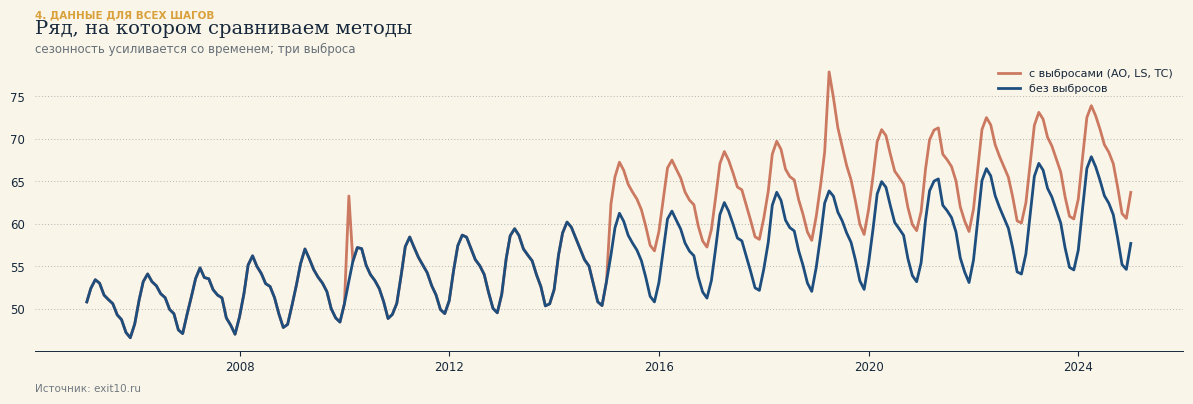

In [50]:
TXT = {
    "sec":   {"ru": "Данные для всех шагов", "en": "Data for all the steps"},
    "title": {"ru": "Ряд, на котором сравниваем методы", "en": "The series on which we compare the methods"},
    "sub":   {"ru": "сезонность усиливается со временем; три выброса", "en": "the seasonality strengthens over time; three outliers"},
    "clean": {"ru": "без выбросов", "en": "without outliers"},
    "dirty": {"ru": "с выбросами (AO, LS, TC)", "en": "with outliers (AO, LS, TC)"},
}
set_section("4", TXT["sec"])

np.random.seed(7)
n = 240; t = np.arange(n)
dates = pd.date_range("2005-01-31", periods=n, freq="ME")
trend_true = 50 + 0.05*t
seas_true = (1 + t/n) * (3*np.sin(2*np.pi*t/12) + np.sin(4*np.pi*t/12 + 0.3))
y_clean = trend_true + seas_true + np.random.normal(0, 0.3, n)
shock = np.zeros(n); shock[60] += 10; shock[120:] += 6; shock[170:] += 8*0.7**np.arange(n-170)
y_dirty = y_clean + shock
rmse = lambda a, b: float(np.sqrt(np.nanmean((np.asarray(a) - np.asarray(b))**2)))

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(dates, y_dirty, color=pal["korall"], alpha=0.8, label=tx(TXT["dirty"]))
ax.plot(dates, y_clean, color=pal["lazur"], label=tx(TXT["clean"]))
chart_frame(ax, tx(TXT["title"]), tx(TXT["sub"]), pal=pal)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


In [51]:
MD = {
"ru": r"""
### 4.1. Census Method I/II (1954–1955): первый алгоритм

**Идея.** Убираем тренд скользящим средним, а для каждого календарного месяца берём **среднее по
всем годам** -- это и есть сезонный фактор января, февраля и так далее.

**Проблема.** Один фактор на всю историю. Если сезонность усиливается, метод этого не видит: в
начале ряда он вычитает слишком много, в конце -- слишком мало.
""",
"en": r"""
### 4.1. Census Method I/II (1954–1955): the first algorithm

**The idea.** Remove the trend with a moving average, and for each calendar month take **the average over
all years** -- that is the seasonal factor for January, February and so on.

**The problem.** One factor for the whole history. If the seasonality strengthens, the method does not see
it: at the start of the series it subtracts too much, at the end too little.
""",
}
show_md(MD)



### 4.1. Census Method I/II (1954–1955): первый алгоритм

**Идея.** Убираем тренд скользящим средним, а для каждого календарного месяца берём **среднее по
всем годам** -- это и есть сезонный фактор января, февраля и так далее.

**Проблема.** Один фактор на всю историю. Если сезонность усиливается, метод этого не видит: в
начале ряда он вычитает слишком много, в конце -- слишком мало.


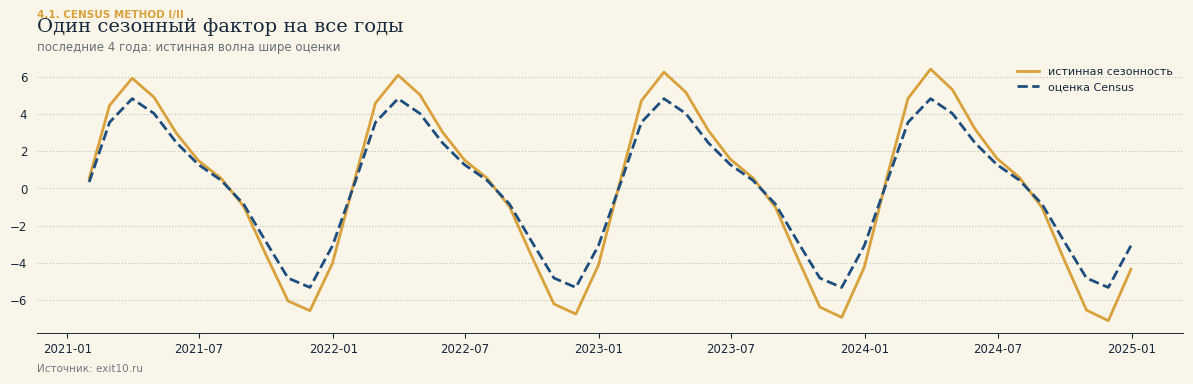

RMSE сезонности: первые 2 года 0.95, середина 0.11, последние 2 года 1.08 -- метод точен только в середине.


In [52]:
TXT = {
    "sec":  {"ru": "Census Method I/II", "en": "Census Method I/II"},
    "title":{"ru": "Один сезонный фактор на все годы", "en": "One seasonal factor for all years"},
    "sub":  {"ru": "последние 4 года: истинная волна шире оценки", "en": "last 4 years: the true wave is wider than the estimate"},
    "est":  {"ru": "оценка Census", "en": "Census estimate"},
    "true": {"ru": "истинная сезонность", "en": "true seasonality"},
    "obs":  {"ru": "RMSE сезонности: первые 2 года {0:.2f}, середина {1:.2f}, последние 2 года {2:.2f} -- метод точен только в середине.",
             "en": "Seasonality RMSE: first 2 years {0:.2f}, middle {1:.2f}, last 2 years {2:.2f} -- the method is accurate only in the middle."},
}
set_section("4.1", TXT["sec"])

s_census = naive_decompose(y_clean)["seasonal"]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates[-48:], seas_true[-48:], color=pal["zoloto"], linewidth=2, label=tx(TXT["true"]))
ax.plot(dates[-48:], s_census[-48:], "--", color=pal["lazur"], label=tx(TXT["est"]))
chart_frame(ax, tx(TXT["title"]), tx(TXT["sub"]), pal=pal)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(tx(TXT["obs"]).format(rmse(s_census[:24], seas_true[:24]), rmse(s_census[108:132], seas_true[108:132]),
                            rmse(s_census[-24:], seas_true[-24:])))


In [53]:
MD = {
"ru": r"""
### 4.2. X-11 (1965): сезонность, которая может меняться

**Какую проблему решает.** Вместо одного среднего по всем годам X-11 сглаживает каждый месяц
**по соседним годам** (окно 3×3 и 3×5). Январь-2020 оценивается по январям 2018–2022, а не по всей
истории. Так сезонный фактор может медленно дрейфовать вместе с реальностью. Для тренда используется
специальный фильтр Хендерсона, который лучше проходит развороты.

**Что осталось.** Фильтру нужны данные **с обеих сторон** от точки. На последних месяцах ряда
«будущих» данных ещё нет, и оценка там ненадёжна (раздел 4.3).
""",
"en": r"""
### 4.2. X-11 (1965): seasonality that can change

**Which problem it solves.** Instead of one average over all years, X-11 smooths each month **over
neighbouring years** (3×3 and 3×5 windows). January 2020 is estimated from the Januaries of 2018–2022
rather than from the whole history. This lets the seasonal factor drift slowly together with reality. For
the trend it uses the special Henderson filter, which follows turning points better.

**What remains.** The filter needs data **on both sides** of a point. In the last months of the series the
"future" data do not exist yet, and the estimate there is unreliable (section 4.3).
""",
}
show_md(MD)



### 4.2. X-11 (1965): сезонность, которая может меняться

**Какую проблему решает.** Вместо одного среднего по всем годам X-11 сглаживает каждый месяц
**по соседним годам** (окно 3×3 и 3×5). Январь-2020 оценивается по январям 2018–2022, а не по всей
истории. Так сезонный фактор может медленно дрейфовать вместе с реальностью. Для тренда используется
специальный фильтр Хендерсона, который лучше проходит развороты.

**Что осталось.** Фильтру нужны данные **с обеих сторон** от точки. На последних месяцах ряда
«будущих» данных ещё нет, и оценка там ненадёжна (раздел 4.3).


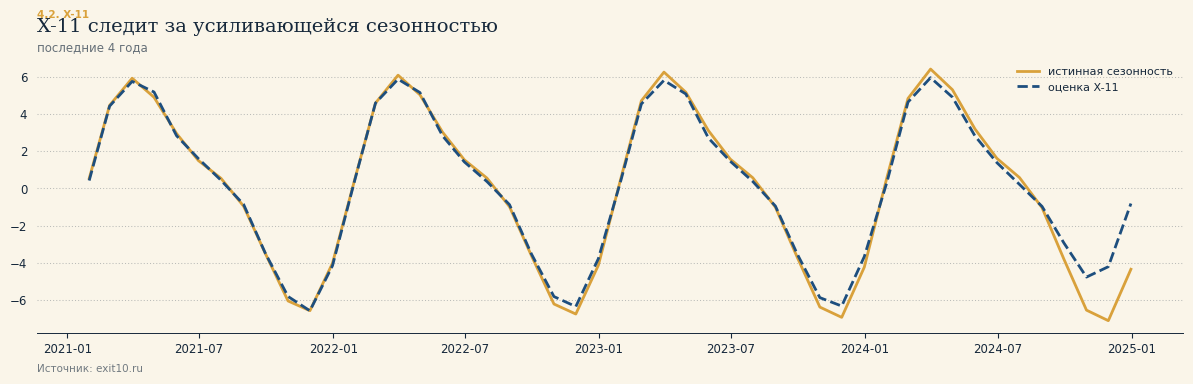

RMSE сезонности по всему ряду: Census 0.65 -> X-11 0.43 (в 1.5 раза точнее).


In [54]:
TXT = {
    "sec":  {"ru": "X-11", "en": "X-11"},
    "title":{"ru": "X-11 следит за усиливающейся сезонностью", "en": "X-11 keeps up with strengthening seasonality"},
    "sub":  {"ru": "последние 4 года", "en": "the last 4 years"},
    "est":  {"ru": "оценка X-11", "en": "X-11 estimate"},
    "true": {"ru": "истинная сезонность", "en": "true seasonality"},
    "obs":  {"ru": "RMSE сезонности по всему ряду: Census {0:.2f} -> X-11 {1:.2f} (в {2:.1f} раза точнее).",
             "en": "Seasonality RMSE over the whole series: Census {0:.2f} -> X-11 {1:.2f} ({2:.1f} times more accurate)."},
}
set_section("4.2", TXT["sec"])

s_x11 = x11_lite(y_clean)["seasonal"]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates[-48:], seas_true[-48:], color=pal["zoloto"], linewidth=2, label=tx(TXT["true"]))
ax.plot(dates[-48:], s_x11[-48:], "--", color=pal["lazur"], label=tx(TXT["est"]))
chart_frame(ax, tx(TXT["title"]), tx(TXT["sub"]), pal=pal)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
r0, r1 = rmse(s_census, seas_true), rmse(s_x11, seas_true)
print(tx(TXT["obs"]).format(r0, r1, r0/r1))


In [55]:
MD = {
"ru": r"""
### 4.3. X-11-ARIMA (1980): край ряда

**Проблема.** Когда выходят новые данные, оценки последних месяцев **пересматриваются** -- иногда
заметно. Аналитик публикует одно число, а через полгода оно другое.

**Идея решения.** Раз фильтру не хватает будущих точек -- дадим ему их: продлим ряд прогнозом
(в оригинале -- моделью ARIMA) на год вперёд и только потом применим фильтр. Последняя настоящая
точка оказывается уже не на краю окна.

Проверим: оценим тренд так, как будто сейчас на год раньше, а потом сравним с оценкой по полному
ряду. Разница -- это и есть пересмотр.
""",
"en": r"""
### 4.3. X-11-ARIMA (1980): the end of the series

**The problem.** When new data come out, the estimates of the last months are **revised** -- sometimes
noticeably. The analyst publishes one number, and six months later it is different.

**The idea of the solution.** If the filter lacks future points, let us give them to it: extend the series
with a forecast (an ARIMA model in the original) a year ahead, and only then apply the filter. The last real
point is then no longer at the edge of the window.

Let us check: estimate the trend as if it were a year earlier, then compare with the estimate on the full
series. The difference is the revision.
""",
}
show_md(MD)



### 4.3. X-11-ARIMA (1980): край ряда

**Проблема.** Когда выходят новые данные, оценки последних месяцев **пересматриваются** -- иногда
заметно. Аналитик публикует одно число, а через полгода оно другое.

**Идея решения.** Раз фильтру не хватает будущих точек -- дадим ему их: продлим ряд прогнозом
(в оригинале -- моделью ARIMA) на год вперёд и только потом применим фильтр. Последняя настоящая
точка оказывается уже не на краю окна.

Проверим: оценим тренд так, как будто сейчас на год раньше, а потом сравним с оценкой по полному
ряду. Разница -- это и есть пересмотр.


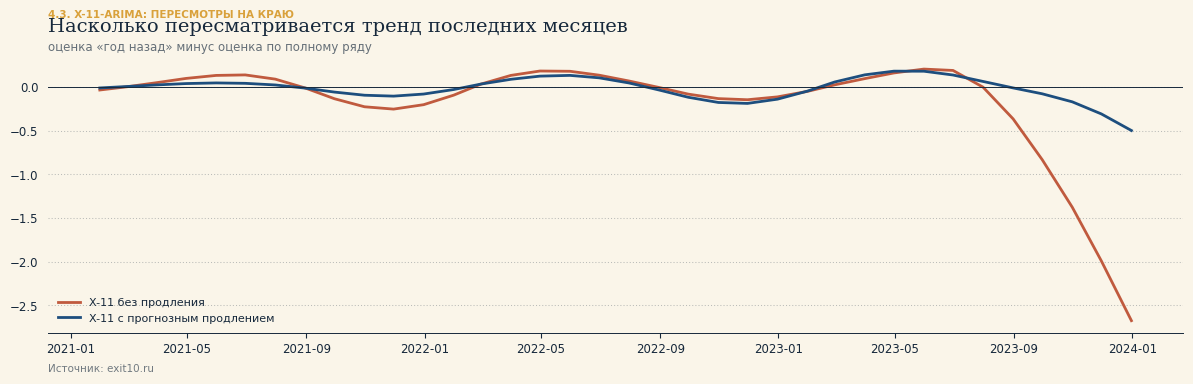

Средний пересмотр на последних 6 месяцах: без продления 1.206, с продлением 0.186.


In [56]:
TXT = {
    "sec":  {"ru": "X-11-ARIMA: пересмотры на краю", "en": "X-11-ARIMA: revisions at the end"},
    "title":{"ru": "Насколько пересматривается тренд последних месяцев", "en": "How much the trend of the last months gets revised"},
    "sub":  {"ru": "оценка «год назад» минус оценка по полному ряду", "en": "the estimate 'a year ago' minus the estimate on the full series"},
    "plain":{"ru": "X-11 без продления", "en": "X-11 without extension"},
    "ext":  {"ru": "X-11 с прогнозным продлением", "en": "X-11 with forecast extension"},
    "obs":  {"ru": "Средний пересмотр на последних 6 месяцах: без продления {0:.3f}, с продлением {1:.3f}.",
             "en": "Mean revision over the last 6 months: without extension {0:.3f}, with extension {1:.3f}."},
}
set_section("4.3", TXT["sec"])

cut = n - 12
final = x11_lite(y_clean)["trend"]
rt_plain = x11_lite(y_clean[:cut])["trend"]
rt_ext = x11_lite(extend_series(y_clean[:cut], extra=12))["trend"][:cut]
rev_plain = rt_plain - final[:cut]
rev_ext = rt_ext - final[:cut]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates[cut-36:cut], rev_plain[-36:], color=pal["korall"], label=tx(TXT["plain"]))
ax.plot(dates[cut-36:cut], rev_ext[-36:], color=pal["lazur"], label=tx(TXT["ext"]))
ax.axhline(0, color=pal["muted"], linewidth=0.7)
chart_frame(ax, tx(TXT["title"]), tx(TXT["sub"]), pal=pal)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(tx(TXT["obs"]).format(np.mean(np.abs(rev_plain[-6:])), np.mean(np.abs(rev_ext[-6:]))))


In [57]:
MD = {
"ru": r"""
**Что осталось.** Пересмотры стали меньше, но не исчезли совсем -- прогноз тоже ошибается. Это
неустранимая плата за то, что будущее неизвестно. И вторая проблема, которую продление никак не
решает: **выбросы**. Разовый шок фильтр «проглатывает» вместе с обычными наблюдениями, и он искажает
сезонность на годы вокруг.

### 4.4. X-12-ARIMA (конец 1990-х): сначала убрать выбросы и календарь

**Какую проблему решает.** Перед фильтром добавляется шаг **regARIMA** -- регрессия, которая явно
оценивает эффекты выбросов (AO, LS, TC) и календаря (Пасха, рабочие дни) и вычитает их. Фильтр X-11
получает уже очищенный ряд. Важно: выброс не «стирается» и не заменяется прогнозом -- вычитается
именно его оценённый эффект.
""",
"en": r"""
**What remains.** Revisions have become smaller but have not disappeared entirely -- the forecast also makes
mistakes. This is the irreducible price of the future being unknown. And a second problem that extension
does not solve at all: **outliers**. The filter "swallows" a one-off shock together with ordinary
observations, and it distorts the seasonality for years around it.

### 4.4. X-12-ARIMA (late 1990s): remove outliers and the calendar first

**Which problem it solves.** A **regARIMA** step is added before the filter -- a regression that explicitly
estimates the effects of outliers (AO, LS, TC) and of the calendar (Easter, working days) and subtracts
them. The X-11 filter receives an already cleaned series. Important: an outlier is not "erased" or replaced
by a forecast -- exactly its estimated effect is subtracted.
""",
}
show_md(MD)



**Что осталось.** Пересмотры стали меньше, но не исчезли совсем -- прогноз тоже ошибается. Это
неустранимая плата за то, что будущее неизвестно. И вторая проблема, которую продление никак не
решает: **выбросы**. Разовый шок фильтр «проглатывает» вместе с обычными наблюдениями, и он искажает
сезонность на годы вокруг.

### 4.4. X-12-ARIMA (конец 1990-х): сначала убрать выбросы и календарь

**Какую проблему решает.** Перед фильтром добавляется шаг **regARIMA** -- регрессия, которая явно
оценивает эффекты выбросов (AO, LS, TC) и календаря (Пасха, рабочие дни) и вычитает их. Фильтр X-11
получает уже очищенный ряд. Важно: выброс не «стирается» и не заменяется прогнозом -- вычитается
именно его оценённый эффект.


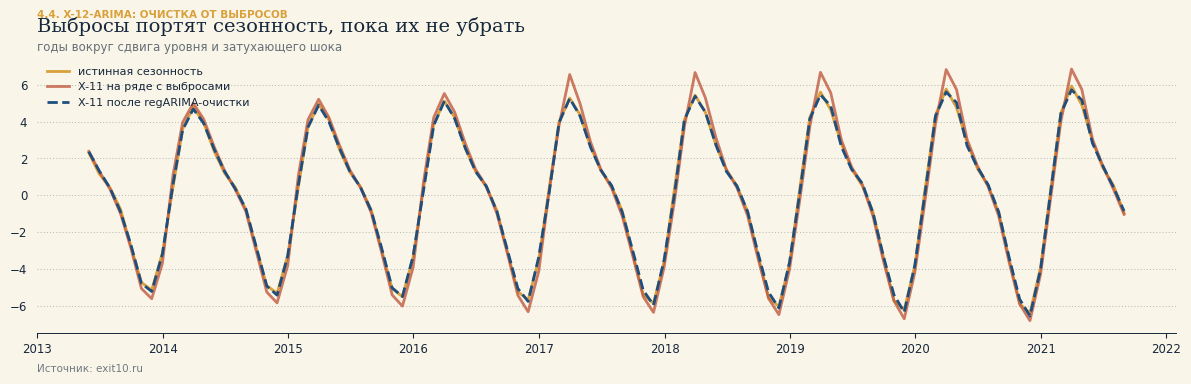

Найдено выбросов: 2010-01 AO, 2015-01 LS, 2019-03 TC
RMSE сезонности: X-11 на грязном ряде 0.58 -> после очистки 0.43.


In [58]:
TXT = {
    "sec":  {"ru": "X-12-ARIMA: очистка от выбросов", "en": "X-12-ARIMA: cleaning out outliers"},
    "title":{"ru": "Выбросы портят сезонность, пока их не убрать", "en": "Outliers spoil the seasonality until they are removed"},
    "sub":  {"ru": "годы вокруг сдвига уровня и затухающего шока", "en": "the years around the level shift and the fading shock"},
    "dirty":{"ru": "X-11 на ряде с выбросами", "en": "X-11 on the series with outliers"},
    "clean":{"ru": "X-11 после regARIMA-очистки", "en": "X-11 after regARIMA cleaning"},
    "true": {"ru": "истинная сезонность", "en": "true seasonality"},
    "found":{"ru": "Найдено выбросов: {0}", "en": "Outliers found: {0}"},
    "obs":  {"ru": "RMSE сезонности: X-11 на грязном ряде {0:.2f} -> после очистки {1:.2f}.",
             "en": "Seasonality RMSE: X-11 on the dirty series {0:.2f} -> after cleaning {1:.2f}."},
}
set_section("4.4", TXT["sec"])

base, _ = _harmonic_trend_cols(n, 12, 2)
search = auto_outlier_search(y_dirty, base)
y_cleaned = search["y_clean"]
s_dirty = x11_lite(y_dirty)["seasonal"]
s_clean = x11_lite(y_cleaned)["seasonal"]

win = slice(100, 200)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates[win], seas_true[win], color=pal["zoloto"], linewidth=2, label=tx(TXT["true"]))
ax.plot(dates[win], s_dirty[win], color=pal["korall"], alpha=0.8, label=tx(TXT["dirty"]))
ax.plot(dates[win], s_clean[win], "--", color=pal["lazur"], label=tx(TXT["clean"]))
chart_frame(ax, tx(TXT["title"]), tx(TXT["sub"]), pal=pal)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(tx(TXT["found"]).format(", ".join(f"{dates[i].strftime('%Y-%m')} {k}" for i, k, _ in sorted(search["outliers"]))))
print(tx(TXT["obs"]).format(rmse(s_dirty, seas_true), rmse(s_clean, seas_true)))


In [59]:
MD = {
"ru": r"""
**Что осталось.** Всё это -- по-прежнему **фильтр**: одни и те же веса применяются к любому ряду, а
метод ничего не говорит о том, насколько он уверен в своей оценке.

### 4.5. X-13ARIMA-SEATS (2011/2012): модель вместо фильтра

**Какую проблему решает.** В X-13 можно заменить фильтр X-11 на **SEATS**. SEATS сначала подбирает под
ряд одну статистическую модель (ARIMA), а затем математически раскладывает её на тренд, сезонность и
шум. Отсюда главное преимущество: модель даёт **доверительный интервал** и честно показывает, что на
краю ряда оценка менее надёжна.

Ниже -- учебная модель `ucm_lite()`. Оговорка: это не сам SEATS, а родственный подход (структурная
модель, UCM), но идея та же -- модель вместо фильтра и ошибка оценки вместо её отсутствия.
""",
"en": r"""
**What remains.** All of this is still a **filter**: the same weights are applied to any series, and the
method says nothing about how confident it is in its estimate.

### 4.5. X-13ARIMA-SEATS (2011/2012): a model instead of a filter

**Which problem it solves.** In X-13 the X-11 filter can be replaced by **SEATS**. SEATS first fits one
statistical model (ARIMA) to the series and then mathematically splits it into trend, seasonality and noise.
Hence the main advantage: the model gives a **confidence interval** and honestly shows that at the end of the
series the estimate is less reliable.

Below is the teaching model `ucm_lite()`. A caveat: it is not SEATS itself but a related approach (a
structural model, UCM), yet the idea is the same -- a model instead of a filter, and an estimation error
instead of none.
""",
}
show_md(MD)



**Что осталось.** Всё это -- по-прежнему **фильтр**: одни и те же веса применяются к любому ряду, а
метод ничего не говорит о том, насколько он уверен в своей оценке.

### 4.5. X-13ARIMA-SEATS (2011/2012): модель вместо фильтра

**Какую проблему решает.** В X-13 можно заменить фильтр X-11 на **SEATS**. SEATS сначала подбирает под
ряд одну статистическую модель (ARIMA), а затем математически раскладывает её на тренд, сезонность и
шум. Отсюда главное преимущество: модель даёт **доверительный интервал** и честно показывает, что на
краю ряда оценка менее надёжна.

Ниже -- учебная модель `ucm_lite()`. Оговорка: это не сам SEATS, а родственный подход (структурная
модель, UCM), но идея та же -- модель вместо фильтра и ошибка оценки вместо её отсутствия.


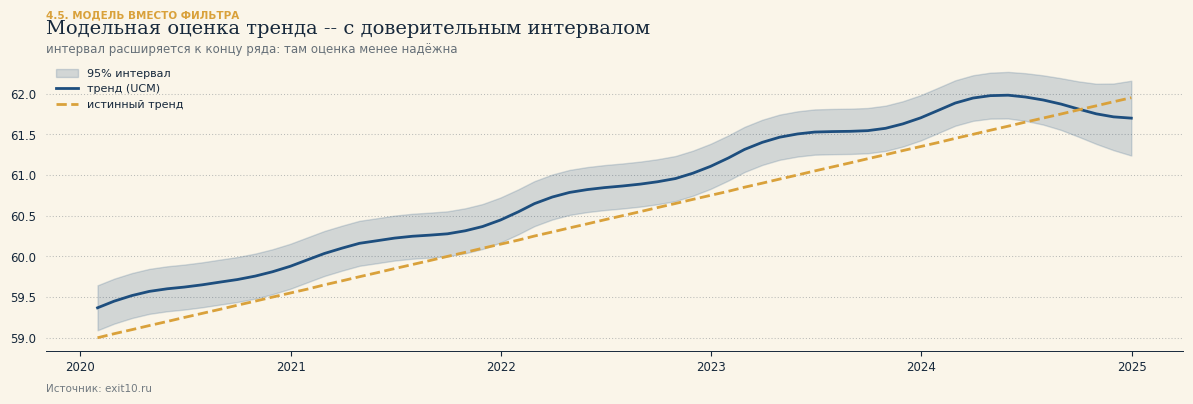

Стандартная ошибка тренда: в середине ряда 0.141, на последних 6 месяцах 0.187.


In [60]:
TXT = {
    "sec":  {"ru": "Модель вместо фильтра", "en": "A model instead of a filter"},
    "title":{"ru": "Модельная оценка тренда -- с доверительным интервалом", "en": "The model-based trend estimate -- with a confidence interval"},
    "sub":  {"ru": "интервал расширяется к концу ряда: там оценка менее надёжна", "en": "the interval widens towards the end of the series: the estimate is less reliable there"},
    "trend":{"ru": "тренд (UCM)", "en": "trend (UCM)"},
    "band": {"ru": "95% интервал", "en": "95% interval"},
    "true": {"ru": "истинный тренд", "en": "true trend"},
    "obs":  {"ru": "Стандартная ошибка тренда: в середине ряда {0:.3f}, на последних 6 месяцах {1:.3f}.",
             "en": "Standard error of the trend: in the middle of the series {0:.3f}, over the last 6 months {1:.3f}."},
}
set_section("4.5", TXT["sec"])

ucm = ucm_lite(y_cleaned)
last = slice(n-60, n)
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.fill_between(dates[last], ucm["trend"][last] - 1.96*ucm["trend_se"][last],
                ucm["trend"][last] + 1.96*ucm["trend_se"][last], color=pal["lazur"], alpha=0.18, label=tx(TXT["band"]))
ax.plot(dates[last], ucm["trend"][last], color=pal["lazur"], label=tx(TXT["trend"]))
# Сравниваем с истинным трендом БЕЗ шока: в ucm_lite подаётся ряд, уже очищенный от
# выбросов, поэтому прибавлять к эталону шок нельзя -- иначе точная оценка выглядит
# как промах на величину сдвига уровня.
ax.plot(dates[last], trend_true[last], "--", color=pal["zoloto"], label=tx(TXT["true"]))
chart_frame(ax, tx(TXT["title"]), tx(TXT["sub"]), pal=pal)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(tx(TXT["obs"]).format(np.mean(ucm["trend_se"][100:140]), np.mean(ucm["trend_se"][-6:])))


In [61]:
MD = {
"ru": r"""
**Что осталось.** Модель хороша настолько, насколько её предположения совпадают с реальностью:
на ряде с резкими изломами она может проиграть простому фильтру. И X-13 по-прежнему работает только с
месячными и квартальными данными с одним сезонным периодом.

### 4.6. JDemetra+ (с 2015 года -- стандарт ЕС): свобода сочетаний

Корректировка всегда состоит из двух шагов: **препроцессинг** (убрать выбросы и календарь) и
**декомпозиция** (разделить на тренд и сезонность). В старых программах эти шаги жёстко сцеплены:
в X-13 препроцессинг всегда regARIMA, в TRAMO-SEATS декомпозиция всегда SEATS. JDemetra+, который
Евростат рекомендует всем статслужбам и центробанкам ЕС, разделил шаги -- можно взять любой
препроцессинг и любую декомпозицию. Практическая польза: если ваша цифра разошлась с цифрой ЕЦБ, можно
менять шаги по одному и найти, откуда взялась разница.

### 4.7. Итог эволюции одним графиком
""",
"en": r"""
**What remains.** A model is only as good as the match between its assumptions and reality: on a series
with abrupt breaks it can lose to a simple filter. And X-13 still works only with monthly and quarterly data
with a single seasonal period.

### 4.6. JDemetra+ (the EU standard since 2015): freedom of combination

Adjustment always consists of two steps: **pre-processing** (removing outliers and the calendar) and
**decomposition** (splitting into trend and seasonality). In the older programs these steps are rigidly
coupled: in X-13 the pre-processing is always regARIMA, in TRAMO-SEATS the decomposition is always SEATS.
JDemetra+, which Eurostat recommends to all EU statistical offices and central banks, separated the steps --
you can take any pre-processing and any decomposition. The practical benefit: if your figure differs from the
ECB's, you can change the steps one at a time and find where the difference comes from.

### 4.7. The evolution in one chart
""",
}
show_md(MD)



**Что осталось.** Модель хороша настолько, насколько её предположения совпадают с реальностью:
на ряде с резкими изломами она может проиграть простому фильтру. И X-13 по-прежнему работает только с
месячными и квартальными данными с одним сезонным периодом.

### 4.6. JDemetra+ (с 2015 года -- стандарт ЕС): свобода сочетаний

Корректировка всегда состоит из двух шагов: **препроцессинг** (убрать выбросы и календарь) и
**декомпозиция** (разделить на тренд и сезонность). В старых программах эти шаги жёстко сцеплены:
в X-13 препроцессинг всегда regARIMA, в TRAMO-SEATS декомпозиция всегда SEATS. JDemetra+, который
Евростат рекомендует всем статслужбам и центробанкам ЕС, разделил шаги -- можно взять любой
препроцессинг и любую декомпозицию. Практическая польза: если ваша цифра разошлась с цифрой ЕЦБ, можно
менять шаги по одному и найти, откуда взялась разница.

### 4.7. Итог эволюции одним графиком


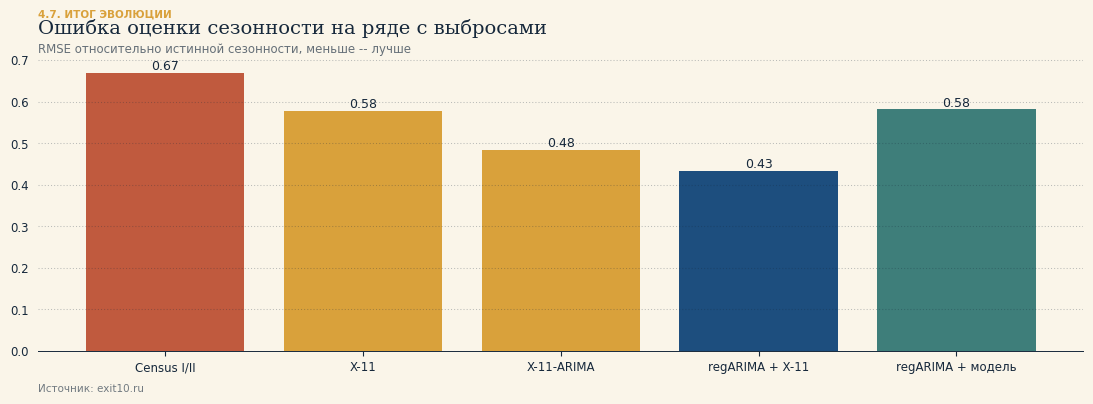

  Census I/II          RMSE = 0.670
  X-11                 RMSE = 0.579
  X-11-ARIMA           RMSE = 0.483
  regARIMA + X-11      RMSE = 0.433
  regARIMA + модель    RMSE = 0.581
Каждый шаг линии Census -> X-11 -> X-11-ARIMA -> regARIMA + X-11 снижает ошибку: да.
Модельный подход по RMSE уступает regARIMA + X-11. Его сила не в меньшей ошибке на любом ряде, а в честном доверительном интервале (раздел 4.5).


In [62]:
TXT = {
    "sec":   {"ru": "Итог эволюции", "en": "The evolution in summary"},
    "title": {"ru": "Ошибка оценки сезонности на ряде с выбросами", "en": "Error of the seasonality estimate on the series with outliers"},
    "sub":   {"ru": "RMSE относительно истинной сезонности, меньше -- лучше", "en": "RMSE against the true seasonality, lower is better"},
    "census":{"ru": "Census I/II", "en": "Census I/II"},
    "x11":   {"ru": "X-11", "en": "X-11"},
    "x11a":  {"ru": "X-11-ARIMA", "en": "X-11-ARIMA"},
    "x12":   {"ru": "regARIMA + X-11", "en": "regARIMA + X-11"},
    "x13":   {"ru": "regARIMA + модель", "en": "regARIMA + model"},
    "row":   {"ru": "  {0:20s} RMSE = {1:.3f}", "en": "  {0:20s} RMSE = {1:.3f}"},
    "note1": {"ru": "Каждый шаг линии Census -> X-11 -> X-11-ARIMA -> regARIMA + X-11 снижает ошибку: {0}.",
              "en": "Each step of the line Census -> X-11 -> X-11-ARIMA -> regARIMA + X-11 reduces the error: {0}."},
    "yes":   {"ru": "да", "en": "yes"},
    "no":    {"ru": "не на этом ряде", "en": "not on this series"},
    "note2": {"ru": "Модельный подход по RMSE {0} regARIMA + X-11. Его сила не в меньшей ошибке на любом ряде, а в честном доверительном интервале (раздел 4.5).",
              "en": "By RMSE the model-based approach {0} regARIMA + X-11. Its strength is not a smaller error on every series but an honest confidence interval (section 4.5)."},
    "better":{"ru": "точнее, чем", "en": "is more accurate than"},
    "worse": {"ru": "уступает", "en": "loses to"},
}
set_section("4.7", TXT["sec"])

scores = {
    "census": rmse(naive_decompose(y_dirty)["seasonal"], seas_true),
    "x11":    rmse(x11_lite(y_dirty)["seasonal"], seas_true),
    "x11a":   rmse(x11_lite(extend_series(y_dirty, extra=12))["seasonal"][:n], seas_true),
    "x12":    rmse(x11_lite(y_cleaned)["seasonal"], seas_true),
    "x13":    rmse(ucm_lite(y_cleaned)["seasonal"], seas_true),
}
fig, ax = plt.subplots(figsize=(11, 4.2))
bars = ax.bar([tx(TXT[k]) for k in scores], list(scores.values()),
              color=[pal["korall"], pal["zoloto"], pal["zoloto"], pal["lazur"], pal["volna"]])
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.2f}", ha="center", va="bottom", fontsize=9)
chart_frame(ax, tx(TXT["title"]), tx(TXT["sub"]), pal=pal)
plt.tight_layout(); plt.show()
for k, v in scores.items():
    print(tx(TXT["row"]).format(tx(TXT[k]), v))
chain = [scores[k] for k in ("census", "x11", "x11a", "x12")]
print(tx(TXT["note1"]).format(tx(TXT["yes"]) if all(a > b for a, b in zip(chain, chain[1:])) else tx(TXT["no"])))
print(tx(TXT["note2"]).format(tx(TXT["better"]) if scores["x13"] < scores["x12"] else tx(TXT["worse"])))


In [63]:
MD = {
"ru": r"""
## 5. Методы вне этой линии

У всей линии X-11 → X-13 общие ограничения: один сезонный период, только целое число наблюдений в
году, месячные или квартальные данные, выбросы надо заранее классифицировать. Каждый из методов ниже
появился, чтобы снять **одно** из этих ограничений.

| Метод | Год | Какую проблему решает | Что остаётся |
|---|---|---|---|
| **STL** | 1990 | Устойчив к выбросам сам, без их поиска и классификации: аномальные точки получают малый вес | Один период, только целый |
| **MSTL** | 2021 | Несколько сезонностей сразу -- например, недельная и годовая у дневных данных | Период всё ещё целый |
| **TBATS** | 2011 | Нецелый период: год = 365,25 дня | Сложная оценка; в простом виде сезонность не меняется |
| **Prophet** | 2017 | Сам находит изломы тренда; рассчитан на тысячи рядов без ручной настройки | Нет строгой теории и доверительных интервалов как у SEATS |
| **UCM** | 1989 | Прозрачная модель: аналитик сам задаёт, из каких частей состоит ряд | Разные разумные модели дают разные ответы |
| **Вейвлеты** | 1980-90-е | Показывают, **когда** сезонный паттерн сломался | Не дают публикуемого сезонно скорректированного ряда |

Для официальной публикации месячных и квартальных данных стандартом остаются X-13ARIMA-SEATS (США,
Россия) и JDemetra+ (ЕС). Остальные методы -- для особых данных и исследовательских задач.
""",
"en": r"""
## 5. Methods outside this line

The whole X-11 → X-13 line shares common limits: one seasonal period, only a whole number of observations
per year, monthly or quarterly data, outliers have to be classified in advance. Each of the methods below
appeared to remove **one** of these limits.

| Method | Year | Which problem it solves | What remains |
|---|---|---|---|
| **STL** | 1990 | Robust to outliers by itself, without finding and classifying them: anomalous points get a small weight | One period, integer only |
| **MSTL** | 2021 | Several seasonalities at once -- e.g. weekly and annual in daily data | The period is still an integer |
| **TBATS** | 2011 | A non-integer period: a year = 365.25 days | Complex estimation; in the simple form the seasonality does not change |
| **Prophet** | 2017 | Finds trend breaks by itself; designed for thousands of series without manual tuning | No rigorous theory and confidence intervals like SEATS |
| **UCM** | 1989 | A transparent model: the analyst specifies which parts the series consists of | Different reasonable models give different answers |
| **Wavelets** | 1980s-90s | Show **when** the seasonal pattern broke | Give no publishable seasonally adjusted series |

For official publication of monthly and quarterly data the standard remains X-13ARIMA-SEATS (US, Russia) and
JDemetra+ (EU). The other methods are for special data and research tasks.
""",
}
show_md(MD)



## 5. Методы вне этой линии

У всей линии X-11 → X-13 общие ограничения: один сезонный период, только целое число наблюдений в
году, месячные или квартальные данные, выбросы надо заранее классифицировать. Каждый из методов ниже
появился, чтобы снять **одно** из этих ограничений.

| Метод | Год | Какую проблему решает | Что остаётся |
|---|---|---|---|
| **STL** | 1990 | Устойчив к выбросам сам, без их поиска и классификации: аномальные точки получают малый вес | Один период, только целый |
| **MSTL** | 2021 | Несколько сезонностей сразу -- например, недельная и годовая у дневных данных | Период всё ещё целый |
| **TBATS** | 2011 | Нецелый период: год = 365,25 дня | Сложная оценка; в простом виде сезонность не меняется |
| **Prophet** | 2017 | Сам находит изломы тренда; рассчитан на тысячи рядов без ручной настройки | Нет строгой теории и доверительных интервалов как у SEATS |
| **UCM** | 1989 | Прозрачная модель: аналитик сам задаёт, из каких частей состоит ряд | Разные разумные модели дают разные ответы |
| **Вейвлеты** | 1980-90-е | Показывают, **когда** сезонный паттерн сломался | Не дают публикуемого сезонно скорректированного ряда |

Для официальной публикации месячных и квартальных данных стандартом остаются X-13ARIMA-SEATS (США,
Россия) и JDemetra+ (ЕС). Остальные методы -- для особых данных и исследовательских задач.


In [64]:
MD = {
"ru": r"""
## 6. Что аналитик видит на выходе: 3MMA SAAR и прогноз

**3MMA SAAR** -- годовой темп роста, посчитанный по последним трём месяцам сезонно скорректированного
ряда. Он быстрее показывает разворот, чем темп «год к году», и спокойнее, чем темп «месяц к месяцу».

Подвох в том, что под одним названием живут **три разные формулы**:

| Формула | Как считается | Кто так считает | В модуле |
|---|---|---|---|
| A | рост средней за 3 месяца к предыдущей средней, в 4-й степени | часто в аналитике | `mode="level_ma"` |
| B | уровень к уровню 3 месяца назад, в 4-й степени | ФРС / BLS для ИПЦ | `mode="level_3m"` |
| C | среднее из трёх месячных приростов, в 12-й степени | **Банк России** | `mode="rate_avg"` |

Если ваша цифра расходится с цифрой ЦБ, сначала проверьте формулу, а потом уже данные.

**Прогноз** в модуле строится продлением тренда и сезонности. Его доверительный интервал --
**нижняя оценка**: модель считает тренд детерминированным, а у реальных рядов он случайный. Для
публикации берите интервалы из X-13 (`method="x13_real"`).
""",
"en": r"""
## 6. What the analyst sees at the output: 3MMA SAAR and the forecast

**3MMA SAAR** is an annual growth rate computed from the last three months of the seasonally adjusted
series. It shows a turning point faster than the year-on-year rate and is calmer than the month-on-month
rate.

The catch is that **three different formulas** live under one name:

| Formula | How it is computed | Who computes it this way | In the module |
|---|---|---|---|
| A | growth of the 3-month average over the previous average, to the 4th power | common in analytics | `mode="level_ma"` |
| B | level to level 3 months earlier, to the 4th power | the Fed / BLS for CPI | `mode="level_3m"` |
| C | average of three monthly growth rates, to the 12th power | **the Bank of Russia** | `mode="rate_avg"` |

If your figure differs from the CBR's, check the formula first and the data second.

**The forecast** in the module is built by extending the trend and the seasonality. Its confidence interval is
**a lower bound**: the model treats the trend as deterministic, while in real series it is random. For
publication take the intervals from X-13 (`method="x13_real"`).
""",
}
show_md(MD)



## 6. Что аналитик видит на выходе: 3MMA SAAR и прогноз

**3MMA SAAR** -- годовой темп роста, посчитанный по последним трём месяцам сезонно скорректированного
ряда. Он быстрее показывает разворот, чем темп «год к году», и спокойнее, чем темп «месяц к месяцу».

Подвох в том, что под одним названием живут **три разные формулы**:

| Формула | Как считается | Кто так считает | В модуле |
|---|---|---|---|
| A | рост средней за 3 месяца к предыдущей средней, в 4-й степени | часто в аналитике | `mode="level_ma"` |
| B | уровень к уровню 3 месяца назад, в 4-й степени | ФРС / BLS для ИПЦ | `mode="level_3m"` |
| C | среднее из трёх месячных приростов, в 12-й степени | **Банк России** | `mode="rate_avg"` |

Если ваша цифра расходится с цифрой ЦБ, сначала проверьте формулу, а потом уже данные.

**Прогноз** в модуле строится продлением тренда и сезонности. Его доверительный интервал --
**нижняя оценка**: модель считает тренд детерминированным, а у реальных рядов он случайный. Для
публикации берите интервалы из X-13 (`method="x13_real"`).


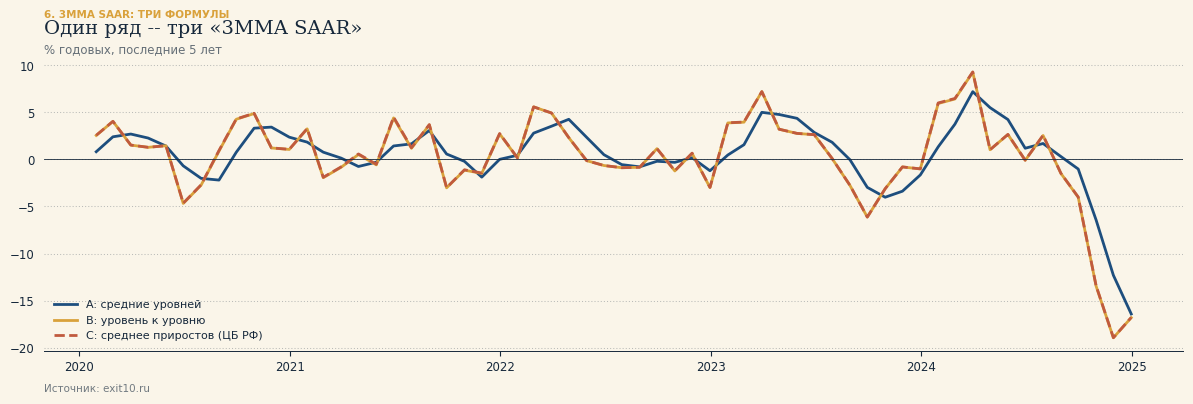

Наибольшее расхождение формул A и C за 5 лет: 6.99 п.п.


In [65]:
TXT = {
    "sec":  {"ru": "3MMA SAAR: три формулы", "en": "3MMA SAAR: three formulas"},
    "title":{"ru": "Один ряд -- три «3MMA SAAR»", "en": "One series -- three '3MMA SAAR's"},
    "sub":  {"ru": "% годовых, последние 5 лет", "en": "% annualised, the last 5 years"},
    "A":    {"ru": "A: средние уровней", "en": "A: averages of levels"},
    "B":    {"ru": "B: уровень к уровню", "en": "B: level to level"},
    "C":    {"ru": "C: среднее приростов (ЦБ РФ)", "en": "C: average of growth rates (CBR)"},
    "obs":  {"ru": "Наибольшее расхождение формул A и C за 5 лет: {0:.2f} п.п.",
             "en": "Largest divergence between formulas A and C over 5 years: {0:.2f} pp."},
}
set_section("6", TXT["sec"])

sa_level = x11_lite(y_cleaned)["sa"]
saar = {m: three_month_ma_saar(sa_level, mode=m)[1].values for m in ("level_ma", "level_3m", "rate_avg")}
last = slice(n-60, n)
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(dates[last], saar["level_ma"][last], color=pal["lazur"], label=tx(TXT["A"]))
ax.plot(dates[last], saar["level_3m"][last], color=pal["zoloto"], label=tx(TXT["B"]))
ax.plot(dates[last], saar["rate_avg"][last], "--", color=pal["korall"], label=tx(TXT["C"]))
ax.axhline(0, color=pal["muted"], linewidth=0.6)
chart_frame(ax, tx(TXT["title"]), tx(TXT["sub"]), pal=pal)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(tx(TXT["obs"]).format(np.nanmax(np.abs(saar["level_ma"][last] - saar["rate_avg"][last]))))


In [66]:
MD = {
"ru": r"""
## 7. Одна функция для реальных данных: `analyze_series()`

Всё, что было выше, собрано в одну функцию. Она сама:

- переводит данные в уровень (`input_format="level" | "mom" | "qoq" | "ytd_cumulative"`);
- решает, нужен ли логарифм;
- учитывает православную Пасху и рабочие дни;
- ищет выбросы (с отбеливанием);
- делает сезонную корректировку (`method="x11" | "ucm" | "stl"`, или настоящий X-13 -- `"x13_real"`);
- проверяет качество и объясняет результат словами;
- считает 3MMA SAAR и прогноз.

Ниже -- ряд, похожий на реальную выручку в рублях: растёт, сезонность в процентах, православная Пасха,
два выброса.
""",
"en": r"""
## 7. One function for real data: `analyze_series()`

Everything above is assembled into one function. By itself it:

- brings the data to a level (`input_format="level" | "mom" | "qoq" | "ytd_cumulative"`);
- decides whether a logarithm is needed;
- accounts for Orthodox Easter and working days;
- searches for outliers (with whitening);
- performs the seasonal adjustment (`method="x11" | "ucm" | "stl"`, or the real X-13 -- `"x13_real"`);
- checks the quality and explains the result in words;
- computes 3MMA SAAR and the forecast.

Below is a series resembling real revenue in roubles: it grows, the seasonality is in percent, Orthodox Easter,
two outliers.
""",
}
show_md(MD)



## 7. Одна функция для реальных данных: `analyze_series()`

Всё, что было выше, собрано в одну функцию. Она сама:

- переводит данные в уровень (`input_format="level" | "mom" | "qoq" | "ytd_cumulative"`);
- решает, нужен ли логарифм;
- учитывает православную Пасху и рабочие дни;
- ищет выбросы (с отбеливанием);
- делает сезонную корректировку (`method="x11" | "ucm" | "stl"`, или настоящий X-13 -- `"x13_real"`);
- проверяет качество и объясняет результат словами;
- считает 3MMA SAAR и прогноз.

Ниже -- ряд, похожий на реальную выручку в рублях: растёт, сезонность в процентах, православная Пасха,
два выброса.


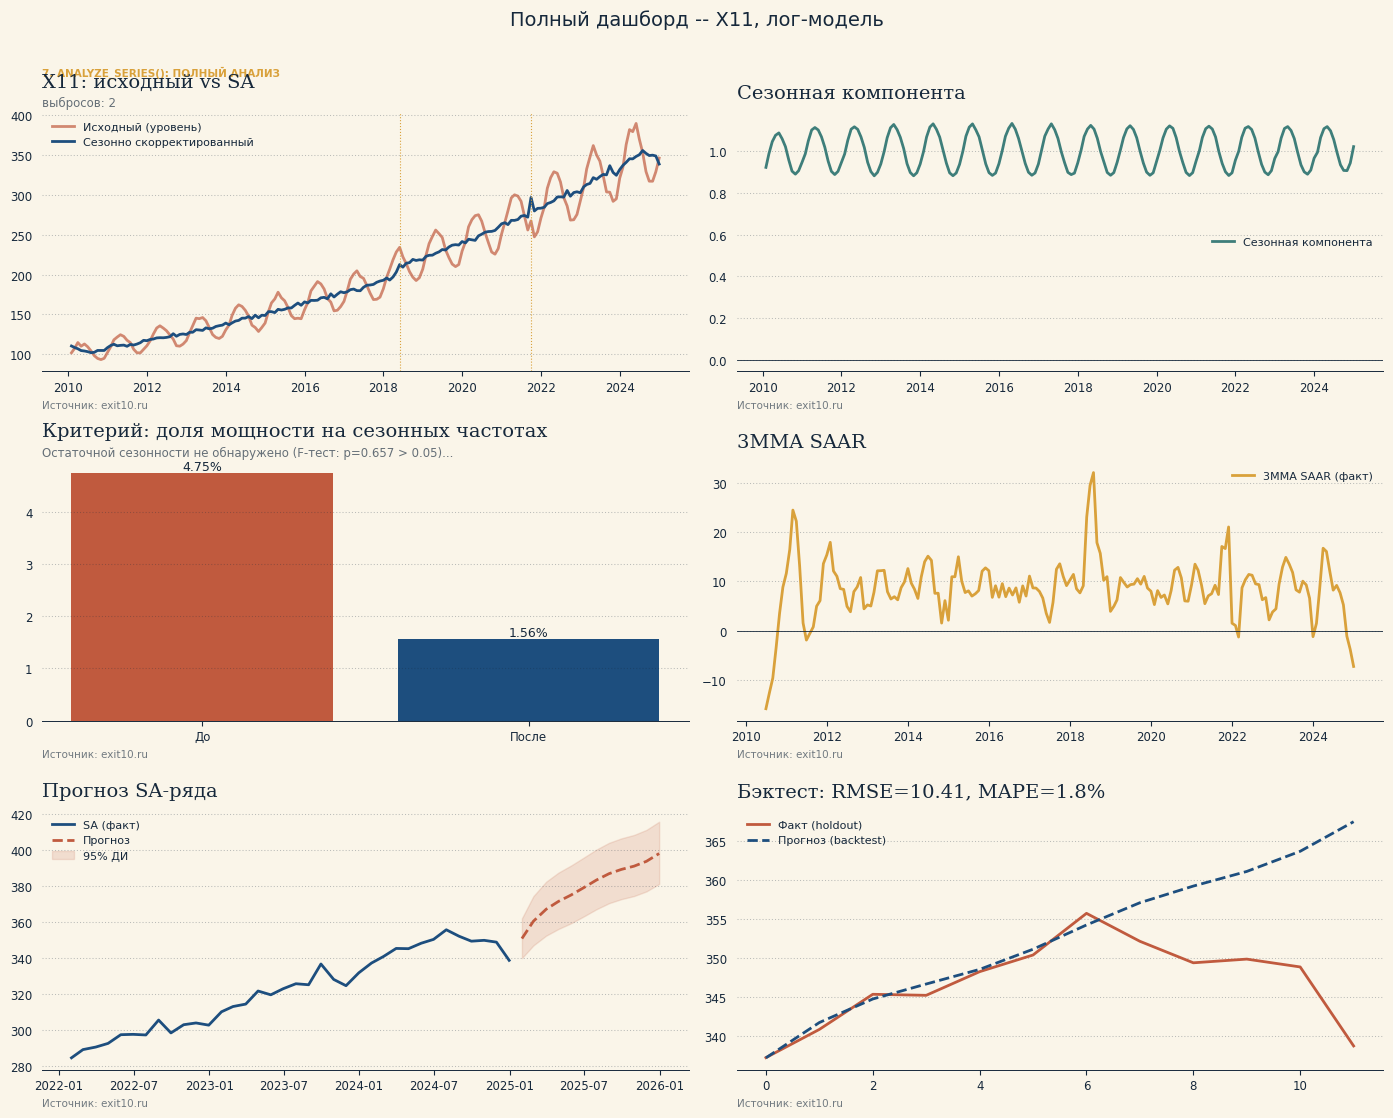

Остаточной сезонности не обнаружено (F-тест: p=0.657 > 0.05). Доля спектральной мощности на сезонных частотах снизилась в 3 раз (4.7% -> 1.56%).

Модель: мультипликативная (с логарифмом)
Выбросы: 2018-05 LS, 2021-09 AO
3MMA SAAR: типичный за последние 3 года 8.4% годовых (истинный рост тренда 8.7%), в самом последнем месяце -7.3%.
Последние месяцы ненадёжны -- это проблема края ряда из раздела 4.3: когда выйдут новые данные, эти значения пересмотрят.


In [67]:
TXT = {
    "sec":   {"ru": "analyze_series(): полный анализ", "en": "analyze_series(): the full analysis"},
    "model": {"ru": "Модель: {0}", "en": "Model: {0}"},
    "log":   {"ru": "мультипликативная (с логарифмом)", "en": "multiplicative (with a logarithm)"},
    "none":  {"ru": "аддитивная", "en": "additive"},
    "outl":  {"ru": "Выбросы: {0}", "en": "Outliers: {0}"},
    "saar":  {"ru": "3MMA SAAR: типичный за последние 3 года {0:.1f}% годовых (истинный рост тренда {1:.1f}%), в самом последнем месяце {2:.1f}%.",
              "en": "3MMA SAAR: typical over the last 3 years {0:.1f}% annualised (true trend growth {1:.1f}%), in the very last month {2:.1f}%."},
    "edge":  {"ru": "Последние месяцы ненадёжны -- это проблема края ряда из раздела 4.3: когда выйдут новые данные, эти значения пересмотрят.",
              "en": "The last months are unreliable -- this is the end-of-series problem from section 4.3: when new data come out, these values will be revised."},
}
set_section("7", TXT["sec"])

np.random.seed(3)
n7 = 180; t7 = np.arange(n7)
d7 = pd.date_range("2010-01-31", periods=n7, freq="ME")
easter = easter_regressor(d7, 8, "orthodox", center=True)
level = 100 * 1.007**t7 * (1 + 0.12*np.sin(2*np.pi*t7/12)) * np.exp(0.04*easter) * np.exp(np.random.normal(0, 0.01, n7))
level[100:] *= 1.05                  # LS: a permanent shift | сдвиг уровня навсегда
level[140] *= 1.08                   # AO: a one-off spike | разовый всплеск
revenue = pd.Series(level, index=d7)

res = analyze_series(revenue, method="x11", plot_mode="full")
print()
print(tx(TXT["model"]).format(tx(TXT[res["transform"]])))
print(tx(TXT["outl"]).format(", ".join(f"{d7[i].strftime('%Y-%m')} {k}" for i, k, _ in sorted(res["outliers"]))))
sh = res["saar_hist"].dropna()
print(tx(TXT["saar"]).format(sh.iloc[-36:].median(), (1.007**12 - 1)*100, sh.iloc[-1]))
print(tx(TXT["edge"]))


In [68]:
MD = {
"ru": r"""
Тот же ряд, но в том виде, в котором его обычно публикует статистика -- темпами «месяц к месяцу».
Функция сама восстановит уровень, а 3MMA SAAR посчитаем по формуле Банка России.
""",
"en": r"""
The same series, but in the form in which statistics usually publish it -- as month-on-month rates. The function
restores the level by itself, and we compute 3MMA SAAR with the Bank of Russia formula.
""",
}
show_md(MD)



Тот же ряд, но в том виде, в котором его обычно публикует статистика -- темпами «месяц к месяцу».
Функция сама восстановит уровень, а 3MMA SAAR посчитаем по формуле Банка России.


Первые темпы м/м, %: [ 5.31  6.95 -4.03  2.57]


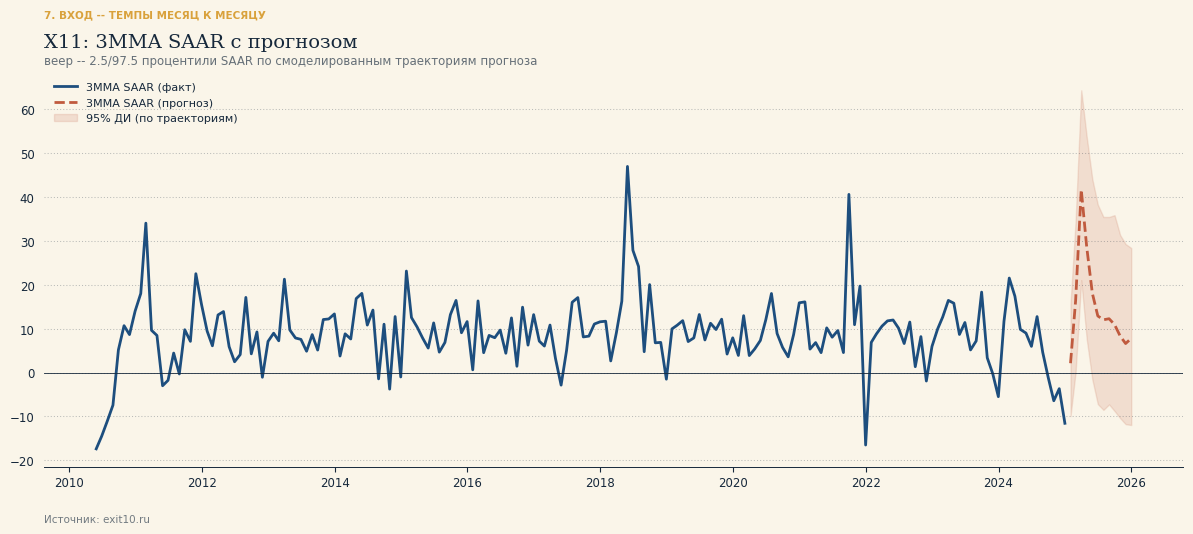

SAAR по формуле ЦБ: типичный за 3 года 8.7% годовых, в последнем месяце -11.6% (край ряда, см. выше).


In [69]:
TXT = {
    "sec":  {"ru": "Вход -- темпы месяц к месяцу", "en": "Input -- month-on-month rates"},
    "head": {"ru": "Первые темпы м/м, %:", "en": "First m/m rates, %:"},
    "same": {"ru": "SAAR по формуле ЦБ: типичный за 3 года {0:.1f}% годовых, в последнем месяце {1:.1f}% (край ряда, см. выше).",
             "en": "SAAR by the CBR formula: typical over 3 years {0:.1f}% annualised, in the last month {1:.1f}% (the end of the series, see above)."},
}
set_section("7", TXT["sec"])

mom = (revenue / revenue.shift(1) - 1).dropna() * 100      # 0.6 means +0.6% | 0.6 означает +0.6%
print(tx(TXT["head"]), np.round(mom.values[:4], 2))
res_mom = analyze_series(mom, input_format="mom", method="x11", saar_mode="rate_avg", plot_mode="saar")
sm = res_mom["saar_hist"].dropna()
print(tx(TXT["same"]).format(sm.iloc[-36:].median(), sm.iloc[-1]))


In [70]:
MD = {
"ru": r"""
**Как применить к своим данным**

```python
df = load_series("my_indicator", source="excel", path="my_indicator.xlsx")   # колонки Date, Value
res = analyze_series(df, input_format="level", method="x11", plot_mode="full")
```

- даты должны быть **концом** периода (31.01, 28.02 …) -- функция предупредит, если это не так;
- если данные -- темпы м/м, передайте `input_format="mom"` и значения в виде прироста (`0.6`, а не `100.6`);
- для западных рядов -- `easter_tradition="catholic"`;
- для свежего шока в последних месяцах -- `outlier_skip_edge=0` (по умолчанию последние 6 месяцев не
  проверяются на выбросы);
- для официальной корректировки поставьте бинарник X-13 и укажите путь: `sx.X13_BIN = "..."`, затем
  `method="x13_real"`.
""",
"en": r"""
**How to apply it to your own data**

```python
df = load_series("my_indicator", source="excel", path="my_indicator.xlsx")   # columns Date, Value
res = analyze_series(df, input_format="level", method="x11", plot_mode="full")
```

- dates must be the **end** of the period (31.01, 28.02 …) -- the function will warn you if they are not;
- if the data are m/m rates, pass `input_format="mom"` and the values as growth (`0.6`, not `100.6`);
- for Western series -- `easter_tradition="catholic"`;
- for a fresh shock in the last months -- `outlier_skip_edge=0` (by default the last 6 months are not checked
  for outliers);
- for official adjustment install the X-13 binary and give its path: `sx.X13_BIN = "..."`, then
  `method="x13_real"`.
""",
}
show_md(MD)



**Как применить к своим данным**

```python
df = load_series("my_indicator", source="excel", path="my_indicator.xlsx")   # колонки Date, Value
res = analyze_series(df, input_format="level", method="x11", plot_mode="full")
```

- даты должны быть **концом** периода (31.01, 28.02 …) -- функция предупредит, если это не так;
- если данные -- темпы м/м, передайте `input_format="mom"` и значения в виде прироста (`0.6`, а не `100.6`);
- для западных рядов -- `easter_tradition="catholic"`;
- для свежего шока в последних месяцах -- `outlier_skip_edge=0` (по умолчанию последние 6 месяцев не
  проверяются на выбросы);
- для официальной корректировки поставьте бинарник X-13 и укажите путь: `sx.X13_BIN = "..."`, затем
  `method="x13_real"`.


In [71]:
MD = {
"ru": r"""
## 8. Открытые вопросы

Даже лучшие современные методы не решают всего. Вот что остаётся открытым -- и о чём полезно помнить,
читая любую сезонно скорректированную цифру.

1. **Пересмотры на краю ряда.** Последние месяцы всегда оценены хуже остальных и будут пересмотрены.
   Прогнозное продление уменьшает пересмотры, но не убирает их: будущее неизвестно.
2. **Структурные сломы.** Когда сезонный паттерн резко меняется (пандемия, санкции, смена методики),
   методы, рассчитанные на плавный дрейф, неделями и месяцами «путают» новое поведение с выбросом или
   со старой сезонностью.
3. **Выбросы в самом конце.** Свежий шок трудно отличить от начала нового тренда -- для этого нужны
   следующие наблюдения, которых ещё нет.
4. **Выбор модели.** Логарифм или нет, какая ARIMA, какой календарь -- разумные варианты дают разные
   ответы. Автоматика помогает, но не отменяет суждения аналитика.
5. **Высокочастотные данные.** Дневные и недельные ряды с несколькими сезонностями до сих пор не имеют
   общепринятого официального стандарта; JDemetra+ v3 и MSTL/TBATS -- шаги в эту сторону.
6. **Неопределённость.** Фильтровые методы вообще не говорят, насколько они уверены; модельные говорят,
   но при условии, что модель верна. Честная оценка ошибки сезонно скорректированного ряда --
   по-прежнему сложная задача.
""",
"en": r"""
## 8. Open questions

Even the best modern methods do not solve everything. Here is what remains open -- and what is worth
remembering when reading any seasonally adjusted figure.

1. **Revisions at the end of the series.** The last months are always estimated worse than the rest and will
   be revised. Forecast extension reduces revisions but does not remove them: the future is unknown.
2. **Structural breaks.** When the seasonal pattern changes abruptly (a pandemic, sanctions, a change of
   methodology), methods designed for smooth drift confuse the new behaviour with an outlier or with the old
   seasonality for weeks and months.
3. **Outliers at the very end.** A fresh shock is hard to tell from the start of a new trend -- that needs the
   next observations, which do not exist yet.
4. **Model choice.** Logarithm or not, which ARIMA, which calendar -- reasonable options give different
   answers. Automation helps but does not replace the analyst's judgement.
5. **High-frequency data.** Daily and weekly series with several seasonalities still have no generally
   accepted official standard; JDemetra+ v3 and MSTL/TBATS are steps in that direction.
6. **Uncertainty.** Filter methods say nothing about how confident they are; model-based ones do, but only on
   condition that the model is right. An honest estimate of the error of a seasonally adjusted series is still
   a hard problem.
""",
}
show_md(MD)



## 8. Открытые вопросы

Даже лучшие современные методы не решают всего. Вот что остаётся открытым -- и о чём полезно помнить,
читая любую сезонно скорректированную цифру.

1. **Пересмотры на краю ряда.** Последние месяцы всегда оценены хуже остальных и будут пересмотрены.
   Прогнозное продление уменьшает пересмотры, но не убирает их: будущее неизвестно.
2. **Структурные сломы.** Когда сезонный паттерн резко меняется (пандемия, санкции, смена методики),
   методы, рассчитанные на плавный дрейф, неделями и месяцами «путают» новое поведение с выбросом или
   со старой сезонностью.
3. **Выбросы в самом конце.** Свежий шок трудно отличить от начала нового тренда -- для этого нужны
   следующие наблюдения, которых ещё нет.
4. **Выбор модели.** Логарифм или нет, какая ARIMA, какой календарь -- разумные варианты дают разные
   ответы. Автоматика помогает, но не отменяет суждения аналитика.
5. **Высокочастотные данные.** Дневные и недельные ряды с несколькими сезонностями до сих пор не имеют
   общепринятого официального стандарта; JDemetra+ v3 и MSTL/TBATS -- шаги в эту сторону.
6. **Неопределённость.** Фильтровые методы вообще не говорят, насколько они уверены; модельные говорят,
   но при условии, что модель верна. Честная оценка ошибки сезонно скорректированного ряда --
   по-прежнему сложная задача.


In [72]:
MD = {
"ru": r"""
## 9. Итоговая таблица

| Шаг | Какую проблему решил | Что осталось |
|---|---|---|
| Census Method I/II | Корректировку вообще можно делать алгоритмом | Сезонность считается неизменной |
| X-11 | Сезонность может медленно меняться | Ненадёжный край ряда, выбросы |
| X-11-ARIMA | Меньше пересмотров на краю | Выбросы и календарь искажают сезонность |
| X-12-ARIMA (regARIMA) | Выбросы и календарь убираются до фильтра | Фильтр не знает своей точности |
| X-13ARIMA-SEATS | Модель вместо фильтра, доверительные интервалы | Только месячные/квартальные данные, один период |
| JDemetra+ | Любые сочетания шагов, стандарт ЕС, дневные данные | Сложность, не побитово равен X-13 |
| STL, MSTL, TBATS, Prophet | Выбросы без классификации, несколько и нецелые периоды, изломы тренда | Не официальный стандарт |
| Вейвлеты | Когда именно сломалась сезонность | Нет публикуемого ряда |

**Главное, что стоит унести.** Сезонная корректировка -- это не одна кнопка, а цепочка решений:
уровни или темпы, логарифм или нет, какой календарь, какие выбросы, какой метод. Каждое из них видно
в `analyze_series()` отдельным аргументом, и каждое можно проверить числами из раздела 2.
""",
"en": r"""
## 9. Summary table

| Step | Which problem it solved | What remained |
|---|---|---|
| Census Method I/II | Adjustment can be done by an algorithm at all | The seasonality is treated as unchanging |
| X-11 | The seasonality can change slowly | An unreliable end of the series, outliers |
| X-11-ARIMA | Fewer revisions at the end | Outliers and the calendar distort the seasonality |
| X-12-ARIMA (regARIMA) | Outliers and the calendar are removed before the filter | The filter does not know its own accuracy |
| X-13ARIMA-SEATS | A model instead of a filter, confidence intervals | Only monthly/quarterly data, one period |
| JDemetra+ | Any combination of steps, the EU standard, daily data | Complexity, not bit-for-bit equal to X-13 |
| STL, MSTL, TBATS, Prophet | Outliers without classification, several and non-integer periods, trend breaks | Not an official standard |
| Wavelets | When exactly the seasonality broke | No publishable series |

**The main thing to take away.** Seasonal adjustment is not one button but a chain of decisions: levels or rates,
logarithm or not, which calendar, which outliers, which method. Each of them appears in `analyze_series()` as a
separate argument, and each can be checked with the numbers from section 2.
""",
}
show_md(MD)



## 9. Итоговая таблица

| Шаг | Какую проблему решил | Что осталось |
|---|---|---|
| Census Method I/II | Корректировку вообще можно делать алгоритмом | Сезонность считается неизменной |
| X-11 | Сезонность может медленно меняться | Ненадёжный край ряда, выбросы |
| X-11-ARIMA | Меньше пересмотров на краю | Выбросы и календарь искажают сезонность |
| X-12-ARIMA (regARIMA) | Выбросы и календарь убираются до фильтра | Фильтр не знает своей точности |
| X-13ARIMA-SEATS | Модель вместо фильтра, доверительные интервалы | Только месячные/квартальные данные, один период |
| JDemetra+ | Любые сочетания шагов, стандарт ЕС, дневные данные | Сложность, не побитово равен X-13 |
| STL, MSTL, TBATS, Prophet | Выбросы без классификации, несколько и нецелые периоды, изломы тренда | Не официальный стандарт |
| Вейвлеты | Когда именно сломалась сезонность | Нет публикуемого ряда |

**Главное, что стоит унести.** Сезонная корректировка -- это не одна кнопка, а цепочка решений:
уровни или темпы, логарифм или нет, какой календарь, какие выбросы, какой метод. Каждое из них видно
в `analyze_series()` отдельным аргументом, и каждое можно проверить числами из раздела 2.
